In [2]:
import os
import json
import pandas as pd
from typing import List

In [ ]:
def load_parametres(subdir: str, filenames: List[str]) -> pd.DataFrame:
    rows = []
    for filename in filenames:
        path = f"{subdir}/{filename}"
        if os.path.exists(path):
            with open(path, 'r') as file:
                try:
                    data = json.load(file)
                except:
                    print(path)
        else:
            print(path)
            continue
        row = {}
        row['batch_size'] = data['data_size']
        row['num_microbatches'] = data['data_size'] // data['batch_size']
        row['prompt_len'] = data['max_prompt_len']
        row['new_tokens'] = data['max_new_tokens']
        row['time (s)'] = data['inference_time']
        row['throughput (tokens/s)'] = data['throughput']
        row['peak memory GPU:0'], row['peak memory GPU:1'] = data['max_memory_allocated_per_device']
        rows.append(row)
        
        
    return pd.DataFrame(rows)

filenames = []
for batch_size in [8, 16, 24]:
    for prompt_len in [128, 192, 256, 320, 384]:
        # for max_new_tokens in [128, 256, 384]:
            for num_microbatch in [1, 2, 4, 8]:
                filename = f"batch_size={batch_size}-num_microbatch={num_microbatch}-max_prompt_len={prompt_len}-max_new_tokens=1opt-1.3b_stats.json"
                filenames.append(filename)

df = load_parametres('src/results/opt/pipeline_2', filenames)  

In [20]:
df.to_csv('src/results/opt/opt-1.3b-prefill_pipeline_2.csv')

# Analyse

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import string
from typing import List
import matplotlib.lines as mlines

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [12]:
def plot_ratios_and_microbatches_decoder(
    df_1: pd.DataFrame,
    df_2: pd.DataFrame,
    gpus: List[str],
    batch_sizes: List[int] = None,
    new_tokens_list: List[int] = None,
    prompt_lens_list: List[int] = None,
    save_path: str = 'plot.svg',
    figsize_per_row: int = 5,
    bar_width_fraction: float = 0.8,
):

    # ── Параметры ──────────────────────────────────────────────────────────
    if batch_sizes is None:
        batch_sizes = range(8, 64 + 1, 8)
    batch_sizes = list(batch_sizes)

    if new_tokens_list is not None:
        new_tokens_list = list(new_tokens_list)
    if prompt_lens_list is not None:
        prompt_lens_list = list(prompt_lens_list)

    # ── Фильтрация ─────────────────────────────────────────────────────────
    df_1 = df_1.copy()
    df_2 = df_2.copy()

    if batch_sizes is not None:
        df_1 = df_1[df_1['batch_size'].isin(batch_sizes)]
        df_2 = df_2[df_2['batch_size'].isin(batch_sizes)]
    if new_tokens_list is not None:
        df_1 = df_1[df_1['new_tokens'].isin(new_tokens_list)]
        df_2 = df_2[df_2['new_tokens'].isin(new_tokens_list)]
    if prompt_lens_list is not None:
        df_1 = df_1[df_1['prompt_len'].isin(prompt_lens_list)]
        df_2 = df_2[df_2['prompt_len'].isin(prompt_lens_list)]

    df_1['max_gpu'] = df_1[gpus].max(axis=1)
    df_2['max_gpu'] = df_2[gpus].max(axis=1)

    n_rows = len(batch_sizes)
    n_subplots = n_rows * 3
    labels = list(string.ascii_lowercase[:n_subplots])

    plt.rcParams.update({
        'font.size': 13,
        'font.family': 'serif',
        'axes.titlesize': 14,
        'axes.labelsize': 13,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 11,
    })

    # ── Цвета ──────────────────────────────────────────────────────────────
    all_new_tokens = sorted(set(df_1['new_tokens']).union(df_2['new_tokens']))
    cmap_bars = sns.color_palette("colorblind", len(all_new_tokens))
    color_map = {nt: cmap_bars[i] for i, nt in enumerate(all_new_tokens)}

    unique_micro = sorted(df_2['num_microbatches'].unique())
    cmap_micro = ListedColormap(sns.color_palette("YlOrRd", len(unique_micro)))
    norm_micro = BoundaryNorm(
        boundaries=[v - 0.5 for v in unique_micro] + [unique_micro[-1] + 0.5],
        ncolors=len(unique_micro)
    )

    # ── Фигура ─────────────────────────────────────────────────────────────
    # Нижняя полоса: достаточно высокая, чтобы легенда не налезала на буквы.
    # Соотношение: основная сетка : нижняя полоса ≈ 1 : legend_ratio
    legend_ratio = 0.10

    fig = plt.figure(figsize=(24, figsize_per_row * n_rows))

    outer = GridSpec(
        2, 1,
        figure=fig,
        # Добавляем пространство между основной сеткой и полосой легенды,
        # чтобы буква под последней строкой и легенда не пересекались.
        height_ratios=[1, legend_ratio / (1 - legend_ratio)],
        hspace=0.1,
    )

    # Основная сетка: 3 колонки данных, без отдельной колонки под colorbar
    inner = GridSpecFromSubplotSpec(
        n_rows, 3,
        subplot_spec=outer[0],
        width_ratios=[1.2, 1.2, 1.0],
        hspace=0.35,   # вертикальный зазор между строками
        wspace=0.30,
    )

    axes = np.empty((n_rows, 3), dtype=object)
    for i in range(n_rows):
        for j in range(3):
            axes[i, j] = fig.add_subplot(inner[i, j])

    # Нижняя ось для легенды
    ax_leg = fig.add_subplot(outer[1])
    ax_leg.axis('off')

    # ── Вспомогательная функция: grouped bar chart ─────────────────────────
    # letter_pad — насколько буква опущена ниже оси (в единицах transAxes).
    # Маленькое значение → буква ближе к графику.
    LETTER_PAD = -0.15

    def draw_grouped_bars(ax, ratio_pivot, title, ylabel, label):
        if ratio_pivot is None or ratio_pivot.empty:
            ax.axis('off')
            return

        pl      = ratio_pivot.index.values
        nt_cols = ratio_pivot.columns.values
        x = np.arange(len(pl))
        single_width = bar_width_fraction / len(nt_cols)

        for j, nt in enumerate(nt_cols):
            offset = (j - len(nt_cols) / 2 + 0.5) * single_width
            vals   = ratio_pivot[nt].values
            bars   = ax.bar(
                x + offset, vals, single_width,
                color=color_map[nt], label=f'new tokens={nt}', alpha=0.85
            )
            for bar, val in zip(bars, vals):
                ax.text(
                    bar.get_x() + bar.get_width() / 2, val,
                    f"{val:.2f}", ha='center', va='bottom', fontsize=9
                )

        ax.axhline(1.0, linestyle='--', color='red')
        ax.set_xticks(x)
        ax.set_xticklabels(pl)
        ax.set_xlabel("Prompt length")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.3)

        ax.text(
            0.5, LETTER_PAD, f'{label}',
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=13, fontstyle='italic', fontweight='bold',
        )

    # ── Основной цикл ──────────────────────────────────────────────────────
    for i, bs in enumerate(batch_sizes):
        data1 = df_1[df_1['batch_size'] == bs]
        data2 = df_2[df_2['batch_size'] == bs]
        if data1.empty or data2.empty:
            continue

        pivot1_thr = data1.pivot_table(values='throughput (tokens/s)',
                                       index='prompt_len', columns='new_tokens')
        pivot1_mem = data1.pivot_table(values='max_gpu',
                                       index='prompt_len', columns='new_tokens')

        best_idx   = (data2.groupby(['prompt_len', 'new_tokens'])
                          ['throughput (tokens/s)'].idxmax())
        best_data2 = data2.loc[best_idx]

        pivot2_thr  = best_data2.pivot_table(values='throughput (tokens/s)',
                                              index='prompt_len', columns='new_tokens')
        pivot2_mem  = best_data2.pivot_table(values='max_gpu',
                                              index='prompt_len', columns='new_tokens')
        pivot_micro = best_data2.pivot_table(values='num_microbatches',
                                              index='prompt_len', columns='new_tokens')

        ratio_thr = pivot2_thr / pivot1_thr
        ratio_mem = pivot2_mem / pivot1_mem

        lbl_thr   = labels[i * 3]
        lbl_mem   = labels[i * 3 + 1]
        lbl_micro = labels[i * 3 + 2]

        draw_grouped_bars(axes[i, 0], ratio_thr,
                          f"Throughput | batch size={bs}", "Ratio", lbl_thr)
        draw_grouped_bars(axes[i, 1], ratio_mem,
                          f"Memory | batch size={bs}", "Ratio", lbl_mem)

        sns.heatmap(
            pivot_micro,
            annot=True, fmt='.0f',
            cmap=cmap_micro, norm=norm_micro,
            ax=axes[i, 2],
            linewidths=1, linecolor='white',
            cbar=False,
        )
        axes[i, 2].set_title(f"Microbatches | batch size={bs}")
        axes[i, 2].set_xlabel("New tokens")
        axes[i, 2].set_ylabel("Prompt length")

        axes[i, 2].text(
            0.5, LETTER_PAD, f'{lbl_micro}',
            transform=axes[i, 2].transAxes,
            ha='center', va='top',
            fontsize=14, fontstyle='italic', fontweight='bold',
        )

    # ── Нижняя легенда ─────────────────────────────────────────────────────
    bar_handles = [
        mpatches.Patch(facecolor=color_map[nt], label=f'new tokens = {nt}', alpha=0.85)
        for nt in all_new_tokens
    ]

    ax_leg.legend(
        handles=bar_handles,
        loc='upper center',          # прижимаем к верху полосы легенды,
        ncol=len(all_new_tokens),    # чтобы не слипаться с буквами
        title='New tokens',
        title_fontsize=16,
        fontsize=14,
        frameon=True,
        framealpha=0.9,
        edgecolor='#cccccc',
        borderpad=1.0,
        labelspacing=0.7,
        handlelength=1.8,
        handleheight=1.4,
        columnspacing=1.5,
    )

    plt.savefig(save_path, format='svg', bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")

## OPT-1.3B

In [21]:
df_1 = pd.read_csv("src/results/opt/opt-1.3b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/opt/opt-1.3b_pipeline_2.csv")

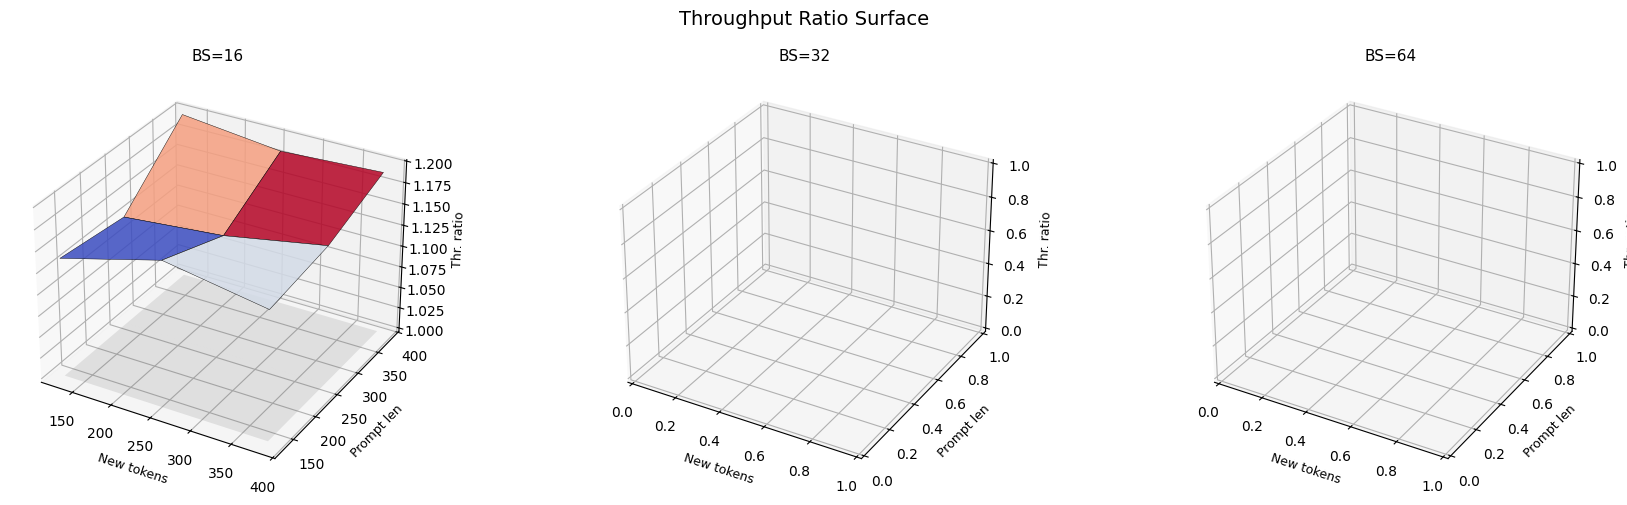

In [15]:
selected_batches = [16, 32, 64]

fig, axes = plt.subplots(1, len(selected_batches),
                         figsize=(6 * len(selected_batches), 5),
                         subplot_kw={'projection': '3d'})

for j, bs in enumerate(selected_batches):
    ax = axes[j]

    data1 = df_1[df_1['batch_size'] == bs].copy()
    data2 = df_2[df_2['batch_size'] == bs].copy()

    best_idx = data2.groupby(['prompt_len', 'new_tokens'])['throughput (tokens/s)'].idxmax()
    best_d2 = data2.loc[best_idx]

    merged = best_d2.merge(data1, on=['prompt_len', 'new_tokens'], suffixes=('_m', '_b'))
    merged['ratio'] = merged['throughput (tokens/s)_m'] / merged['throughput (tokens/s)_b']

    pivot = merged.pivot_table(values='ratio', index='prompt_len', columns='new_tokens')
    X, Y = np.meshgrid(pivot.columns.values, pivot.index.values)
    Z = pivot.values

    surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='k', linewidth=0.3, alpha=0.85)
    ax.set_xlabel('New tokens', fontsize=9)
    ax.set_ylabel('Prompt len', fontsize=9)
    ax.set_zlabel('Thr. ratio', fontsize=9)
    ax.set_title(f'BS={bs}', fontsize=11)

    # Плоскость ratio=1
    ax.plot_surface(X, Y, np.ones_like(Z), alpha=0.15, color='gray')

fig.suptitle('Throughput Ratio Surface', fontsize=14)
plt.tight_layout()
plt.show()

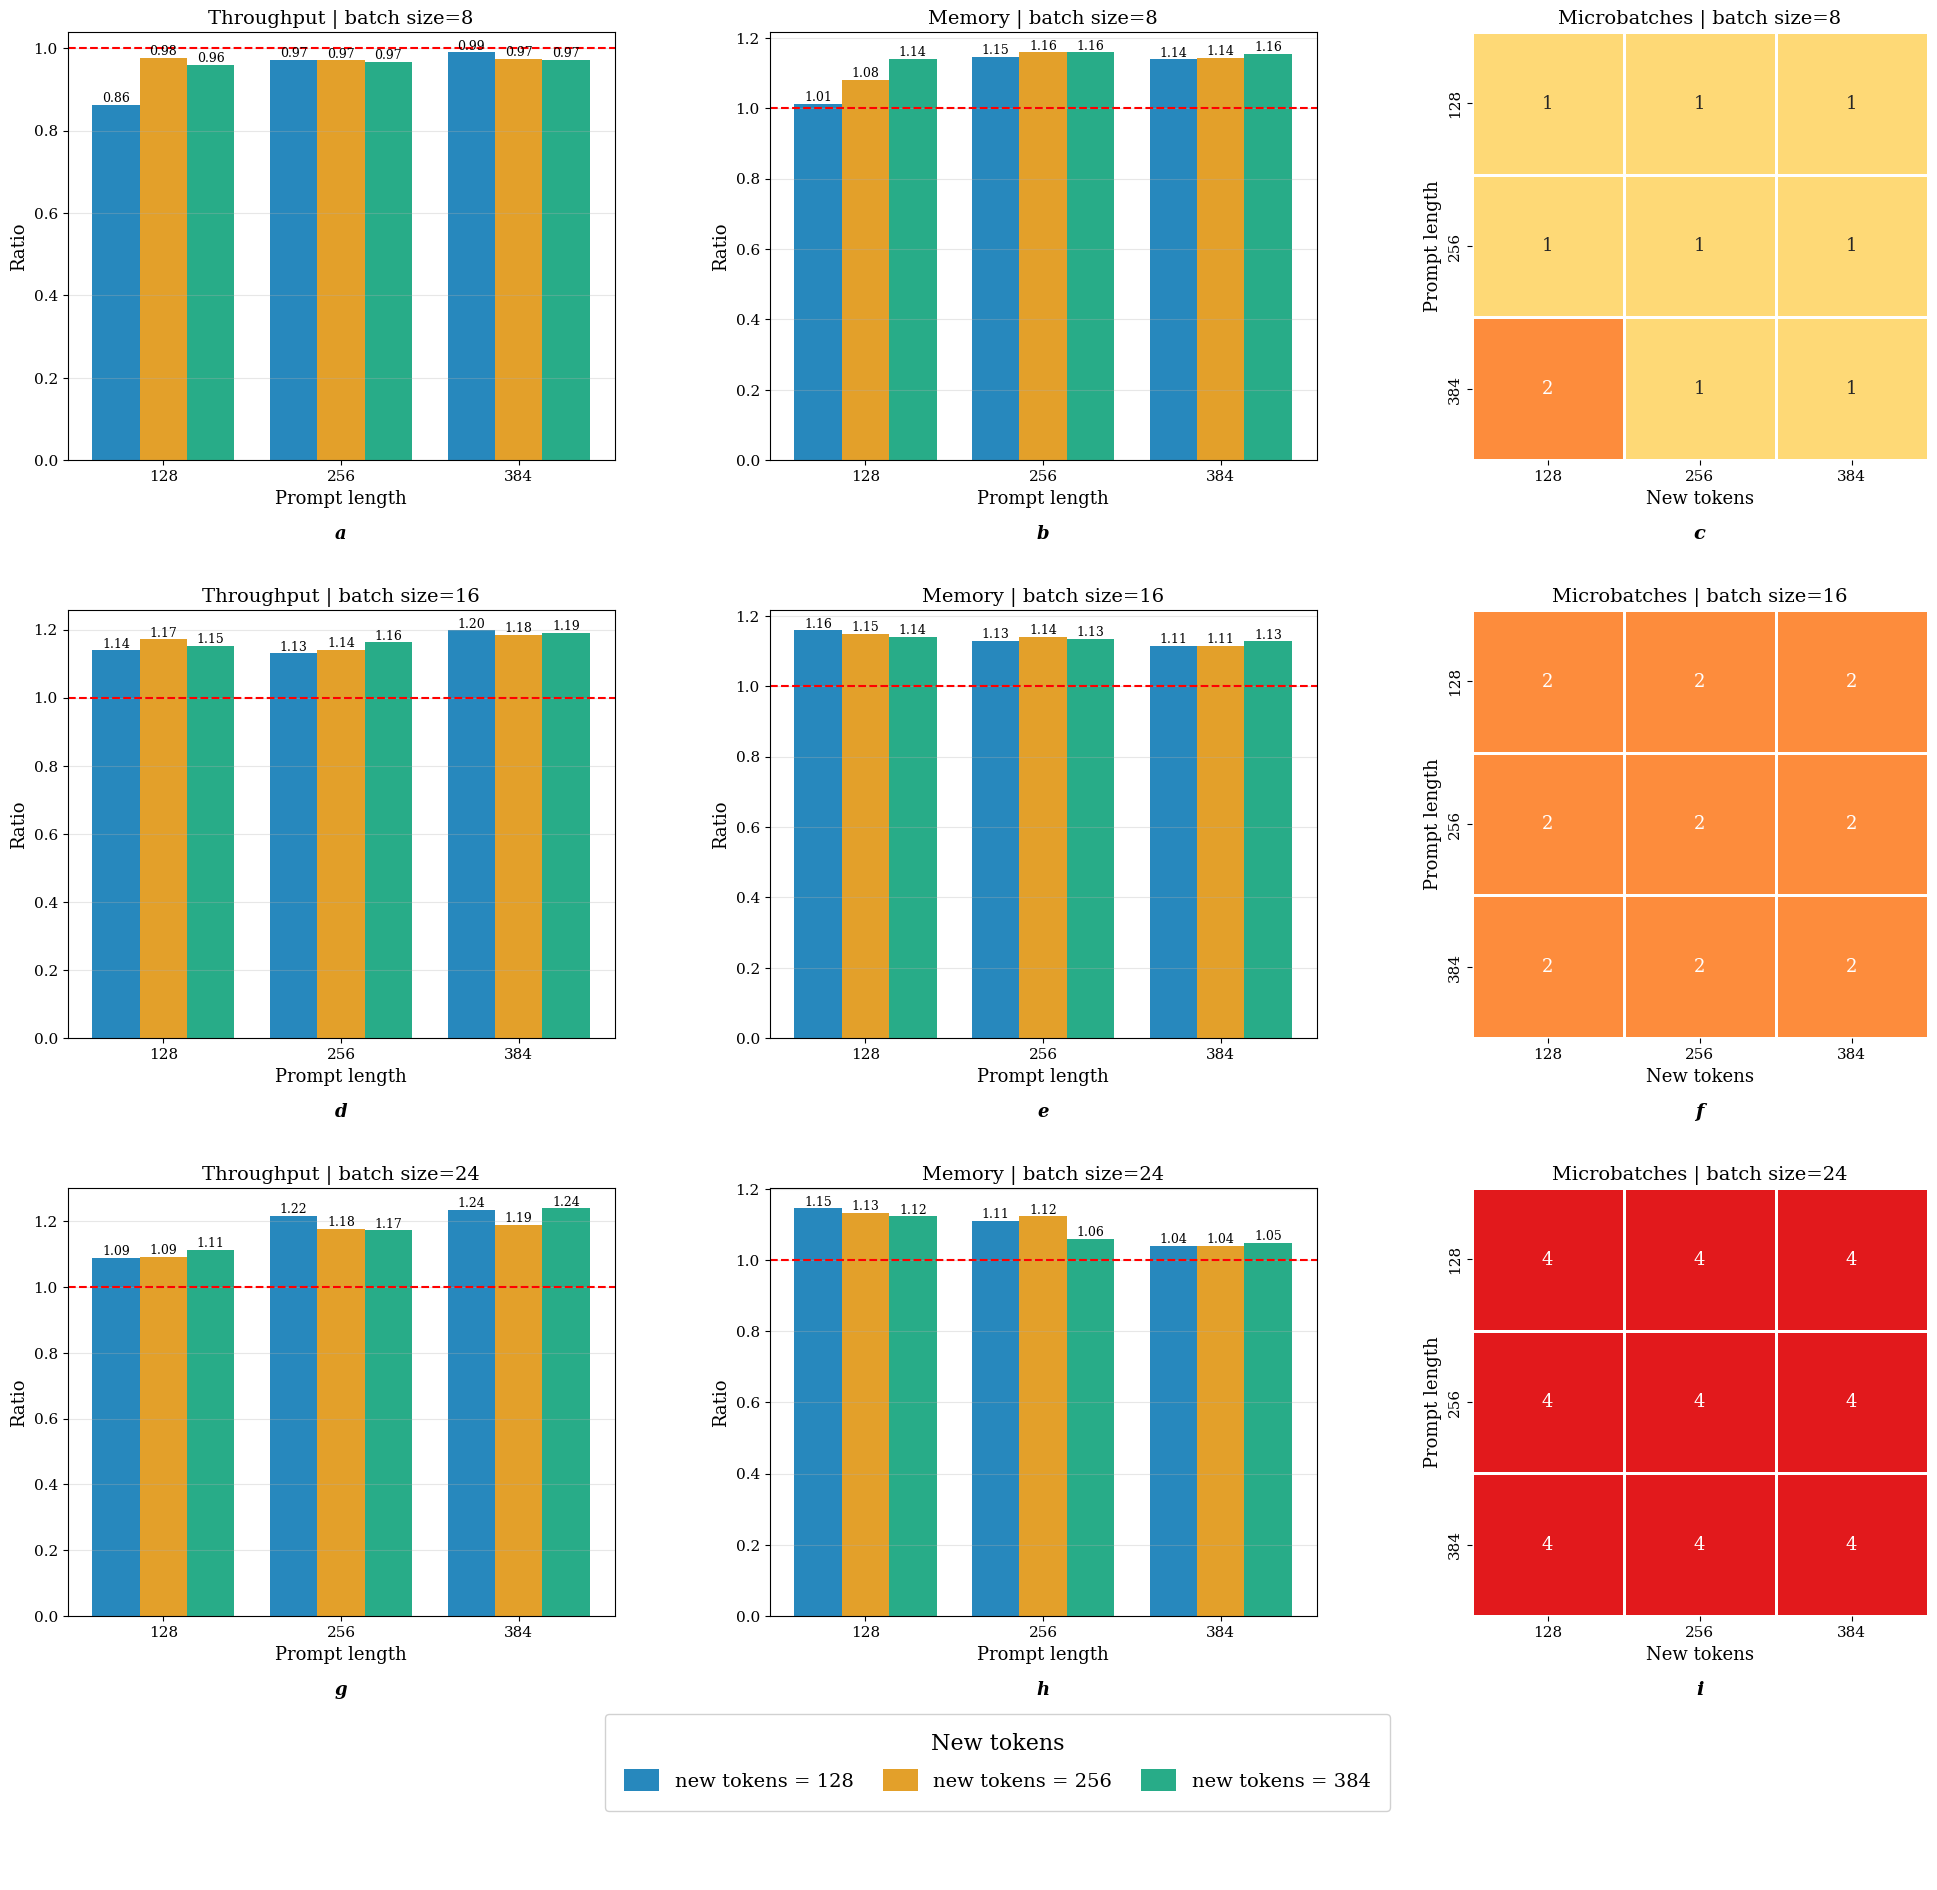

Saved to opt-1.3b.svg


In [17]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1'],
                             batch_sizes=[8, 16, 24],
                             prompt_lens_list=[128, 256, 384],
                             new_tokens_list=[128, 256, 384],
                             figsize_per_row=8, 
                             bar_width_fraction=0.8,
                             save_path="opt-1.3b.svg")

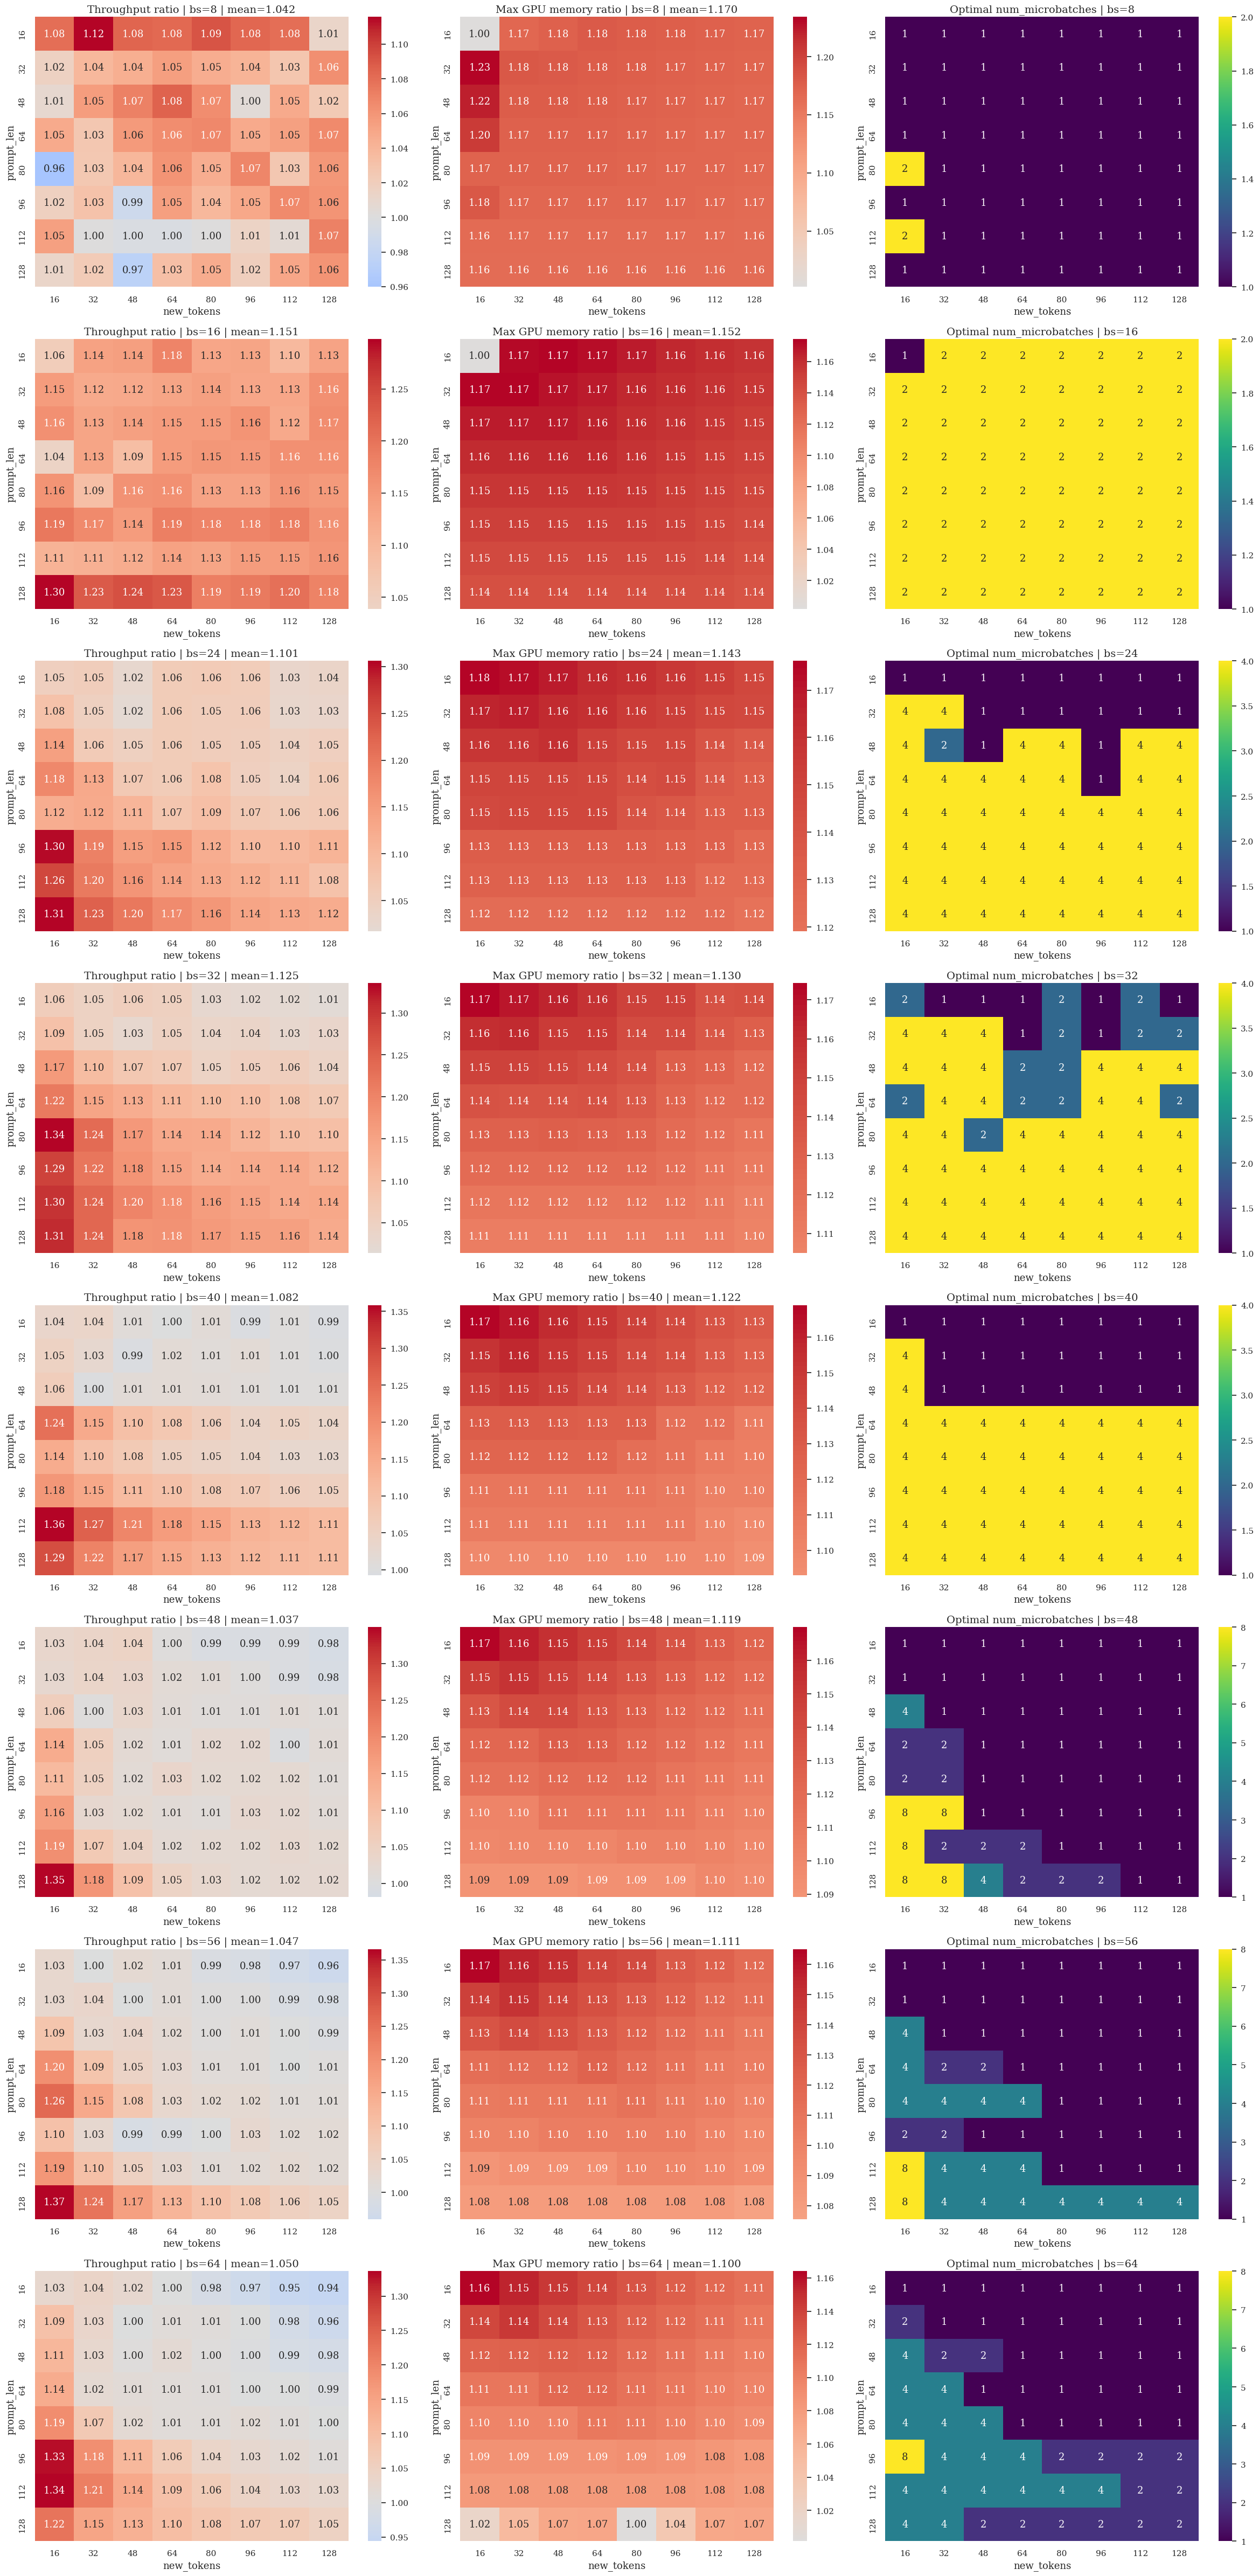

In [ ]:
batch_sizes = range(8, 64 + 1, 8)

fig, axes = plt.subplots(len(batch_sizes), 3, figsize=(24, 6 * len(batch_sizes)))

if len(batch_sizes) == 1:
    axes = [axes]

for i, batch_size in enumerate(batch_sizes):

    data1 = df_1[df_1['batch_size'] == batch_size].copy()
    data1['max_gpu'] = data1[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

    pivot1_thr = data1.pivot_table(
        values='throughput (tokens/s)',
        index='prompt_len',
        columns='new_tokens'
    )

    pivot1_mem = data1.pivot_table(
        values='max_gpu',
        index='prompt_len',
        columns='new_tokens'
    )
    
    data2 = df_2[df_2['batch_size'] == batch_size].copy()
    best_idx = data2.groupby(['prompt_len', 'new_tokens'])['throughput (tokens/s)'].idxmax()
    best_data2 = data2.loc[best_idx].copy()
    best_data2['max_gpu'] = best_data2[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

    pivot2_thr = best_data2.pivot_table(
        values='throughput (tokens/s)',
        index='prompt_len',
        columns='new_tokens'
    )

    pivot2_mem = best_data2.pivot_table(
        values='max_gpu',
        index='prompt_len',
        columns='new_tokens'
    )

    pivot_micro = best_data2.pivot_table(
        values='num_microbatches',
        index='prompt_len',
        columns='new_tokens'
    )

    ratio_thr = pivot2_thr / pivot1_thr
    ratio_mem = pivot2_mem / pivot1_mem

    mean_ratio_thr = np.nanmean(ratio_thr.values)
    mean_ratio_mem = np.nanmean(ratio_mem.values)

    sns.heatmap(ratio_thr, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[i, 0])
    axes[i, 0].set_title(f"Throughput ratio | bs={batch_size} | mean={mean_ratio_thr:.3f}")
    axes[i, 0].set_xlabel("new_tokens")
    axes[i, 0].set_ylabel("prompt_len")

    sns.heatmap(ratio_mem, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[i, 1])
    axes[i, 1].set_title(f"Max GPU memory ratio | bs={batch_size} | mean={mean_ratio_mem:.3f}")
    axes[i, 1].set_xlabel("new_tokens")
    axes[i, 1].set_ylabel("prompt_len")

    # Optimal microbatches
    sns.heatmap(pivot_micro, annot=True, fmt=".0f", cmap="viridis", ax=axes[i, 2])
    axes[i, 2].set_title(f"Optimal num_microbatches | bs={batch_size}")
    axes[i, 2].set_xlabel("new_tokens")
    axes[i, 2].set_ylabel("prompt_len")

plt.tight_layout()
plt.show()

**Задачи:**
1. Провести эксперимент с Deepspeed и transformers
2. провести эксперимент с batch_size = 16, но более большим new_tokens и prompt_len

### opt-1.3b-prefill

In [22]:
df_1 = pd.read_csv("src/results/opt/opt-1.3b-prefill_pipeline_1.csv")
df_2 = pd.read_csv("src/results/opt/opt-1.3b-prefill_pipeline_2.csv")

In [23]:
def plot_ratios_and_microbatches_encoder(
    df_1: pd.DataFrame,
    df_2: pd.DataFrame,
    gpus: List[str],
    batch_sizes: List[int] = None,
    prompt_lens_list: List[int] = None,
    save_path: str = 'plot.svg',
    figsize_per_row: int = 5,
):
    # ── Фильтрация ─────────────────────────────────────────────────────────
    df_1 = df_1.copy()
    df_2 = df_2.copy()

    if batch_sizes is not None:
        df_1 = df_1[df_1['batch_size'].isin(batch_sizes)]
        df_2 = df_2[df_2['batch_size'].isin(batch_sizes)]
    if prompt_lens_list is not None:
        df_1 = df_1[df_1['prompt_len'].isin(prompt_lens_list)]
        df_2 = df_2[df_2['prompt_len'].isin(prompt_lens_list)]

    df_1['max_gpu'] = df_1[gpus].max(axis=1)

    # ── Лучший df_2 по throughput ──────────────────────────────────────────
    best_idx   = df_2.groupby(['prompt_len', 'batch_size'])['throughput (tokens/s)'].idxmax()
    best_data2 = df_2.loc[best_idx].copy()
    best_data2['max_gpu'] = best_data2[gpus].max(axis=1)

    # ── Pivot tables ───────────────────────────────────────────────────────
    pivot_thr      = best_data2.pivot_table(values='throughput (tokens/s)',
                                            index='prompt_len', columns='batch_size')
    pivot_thr_base = df_1.pivot_table(values='throughput (tokens/s)',
                                      index='prompt_len', columns='batch_size')
    pivot_mem      = best_data2.pivot_table(values='max_gpu',
                                            index='prompt_len', columns='batch_size')
    pivot_mem_base = df_1.pivot_table(values='max_gpu',
                                      index='prompt_len', columns='batch_size')
    pivot_micro    = best_data2.pivot_table(values='num_microbatches',
                                            index='prompt_len', columns='batch_size')

    ratio_thr = pivot_thr / pivot_thr_base
    ratio_mem = pivot_mem / pivot_mem_base

    mean_ratio_thr = np.nanmean(ratio_thr.values)
    mean_ratio_mem = np.nanmean(ratio_mem.values)

    all_batch_sizes = sorted(ratio_thr.columns.tolist())

    # ── Стиль ─────────────────────────────────────────────────────────────
    plt.rcParams.update({
        'font.size': 13,
        'font.family': 'serif',
        'axes.titlesize': 14,
        'axes.labelsize': 13,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
    })

    cmap_lines = sns.color_palette("colorblind", len(all_batch_sizes))
    color_map  = {bs: cmap_lines[i] for i, bs in enumerate(all_batch_sizes)}
    markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
    marker_map = {bs: markers[i % len(markers)] for i, bs in enumerate(all_batch_sizes)}

    # ── Фигура: основная сетка (1×3) + нижняя полоса легенды ──────────────
    LETTER_PAD  = -0.18
    legend_ratio = 0.10

    fig = plt.figure(figsize=(24, figsize_per_row))

    outer = GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[1, legend_ratio / (1 - legend_ratio)],
        hspace=0.45,
    )
    inner = GridSpecFromSubplotSpec(
        1, 3,
        subplot_spec=outer[0],
        width_ratios=[1.2, 1.2, 1.0],
        wspace=0.20,
    )

    ax_thr   = fig.add_subplot(inner[0, 0])
    ax_mem   = fig.add_subplot(inner[0, 1])
    ax_micro = fig.add_subplot(inner[0, 2])
    ax_leg   = fig.add_subplot(outer[1])
    ax_leg.axis('off')

    # ── Вспомогательная: line plot ─────────────────────────────────────────
    def draw_line_plot(ax, ratio_pivot, title, ylabel, label, mean_val):
        prompt_lens = ratio_pivot.index.values
        for bs in all_batch_sizes:
            if bs not in ratio_pivot.columns:
                continue
            vals = ratio_pivot[bs].values
            ax.plot(
                prompt_lens, vals,
                color=color_map[bs],
                marker=marker_map[bs],
                linewidth=1.8,
                markersize=6,
                label=f'batch size = {bs}',
            )
            # Подписи значений рядом с точками
            for x, y in zip(prompt_lens, vals):
                if not np.isnan(y):
                    ax.annotate(
                        f'{y:.2f}',
                        xy=(x, y),
                        xytext=(0, 7),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=8.5,
                        color=color_map[bs],
                    )
        ax.axhline(1.0, linestyle='--', color='red')
        ax.set_xlabel("Prompt length")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title}\nmean ratio = {mean_val:.3f}")
        ax.set_xticks(prompt_lens)
        ax.grid(axis='y', alpha=0.8, linestyle='--', linewidth=0.8)
        ax.grid(axis='x', alpha=0.8, linestyle='--', linewidth=0.8)

        ax.text(
            0.5, LETTER_PAD, f'{label}',
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=13, fontstyle='italic', fontweight='bold',
        )

    # ── Line plots ─────────────────────────────────────────────────────────
    draw_line_plot(ax_thr,  ratio_thr, "Throughput ratio", "Ratio", 'a', mean_ratio_thr)
    draw_line_plot(ax_mem,  ratio_mem, "Memory ratio",     "Ratio", 'b', mean_ratio_mem)

    # ── Heatmap ────────────────────────────────────────────────────────────
    unique_micro = sorted(best_data2['num_microbatches'].unique())
    cmap_micro   = ListedColormap(sns.color_palette("YlOrRd", len(unique_micro)))
    norm_micro   = BoundaryNorm(
        boundaries=[v - 0.5 for v in unique_micro] + [unique_micro[-1] + 0.5],
        ncolors=len(unique_micro)
    )

    sns.heatmap(
        pivot_micro,
        annot=True, fmt='.0f',
        cmap=cmap_micro, norm=norm_micro,
        ax=ax_micro,
        linewidths=1, linecolor='white',
        cbar=False,
    )

    ax_micro.set_title("Optimal num_microbatches")
    ax_micro.set_xlabel("batch_size")
    ax_micro.set_ylabel("prompt_len")

    ax_micro.text(
        0.5, LETTER_PAD, 'c',
        transform=ax_micro.transAxes,
        ha='center', va='top',
        fontsize=14, fontstyle='italic', fontweight='bold',
    )

    # ── Нижняя легенда ─────────────────────────────────────────────────────
    line_handles = [
        mlines.Line2D(
            [], [],
            color=color_map[bs],
            marker=marker_map[bs],
            linewidth=1.8,
            markersize=7,
            label=f'batch size = {bs}',
        )
        for bs in all_batch_sizes
    ]

    ax_leg.legend(
        handles=line_handles,
        loc='upper center',
        ncol=len(all_batch_sizes),
        title='Batch size',
        title_fontsize=16,
        fontsize=14,
        frameon=True,
        framealpha=0.9,
        edgecolor='#cccccc',
        borderpad=1.0,
        labelspacing=0.7,
        handlelength=2.0,
        handleheight=1.4,
        columnspacing=1.5,
    )

    plt.savefig(save_path, format='svg', bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")

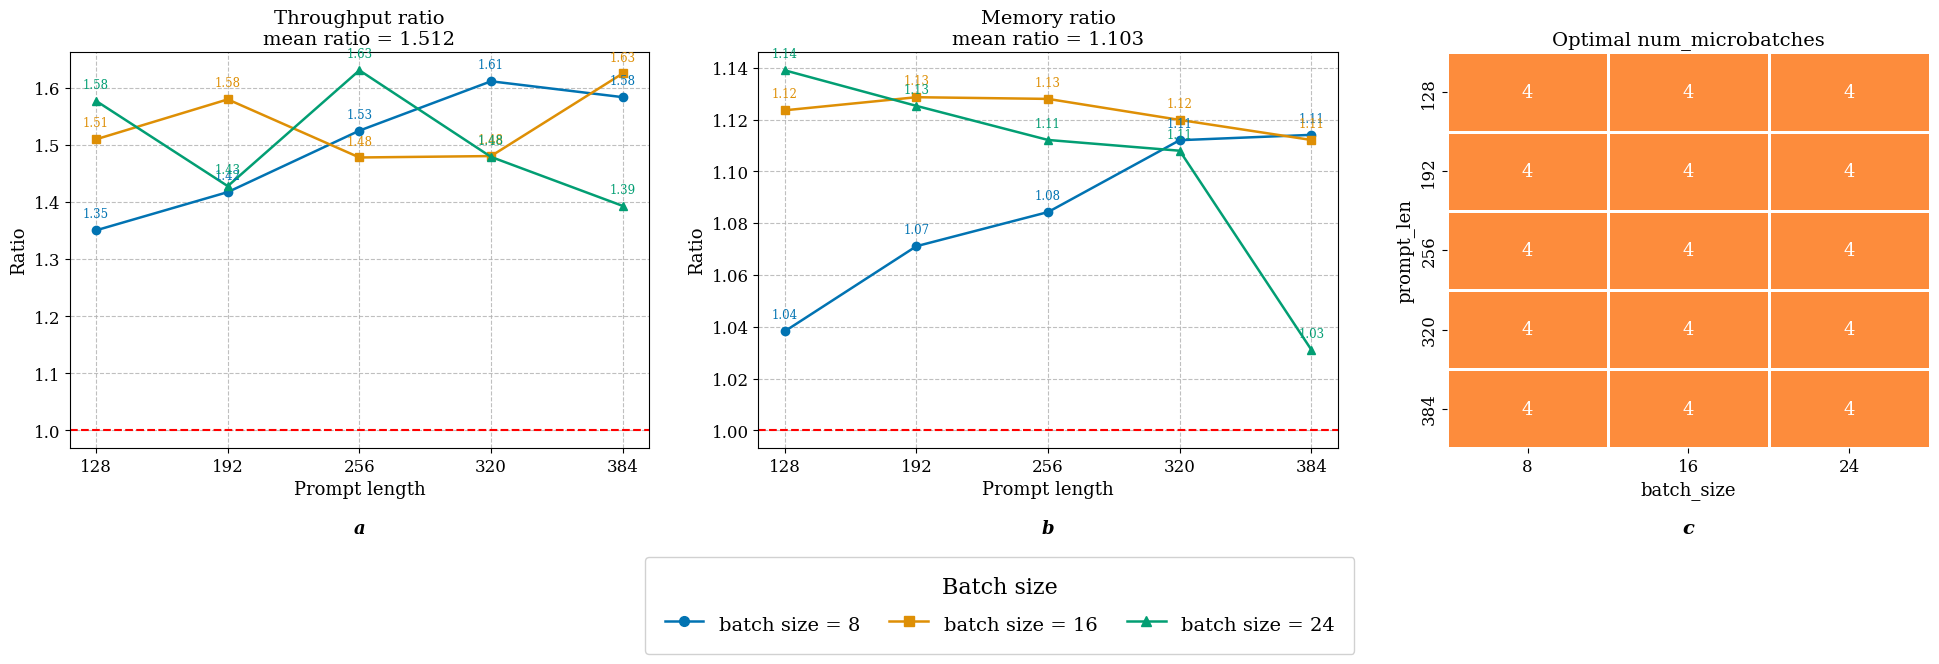

Saved to opt-1.3b-prefill.svg


In [24]:
plot_ratios_and_microbatches_encoder(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1'],
                             batch_sizes=[8, 16, 24],
                             prompt_lens_list=[128, 192, 256, 320, 384],
                             figsize_per_row=7,
                             save_path="opt-1.3b-prefill.svg")

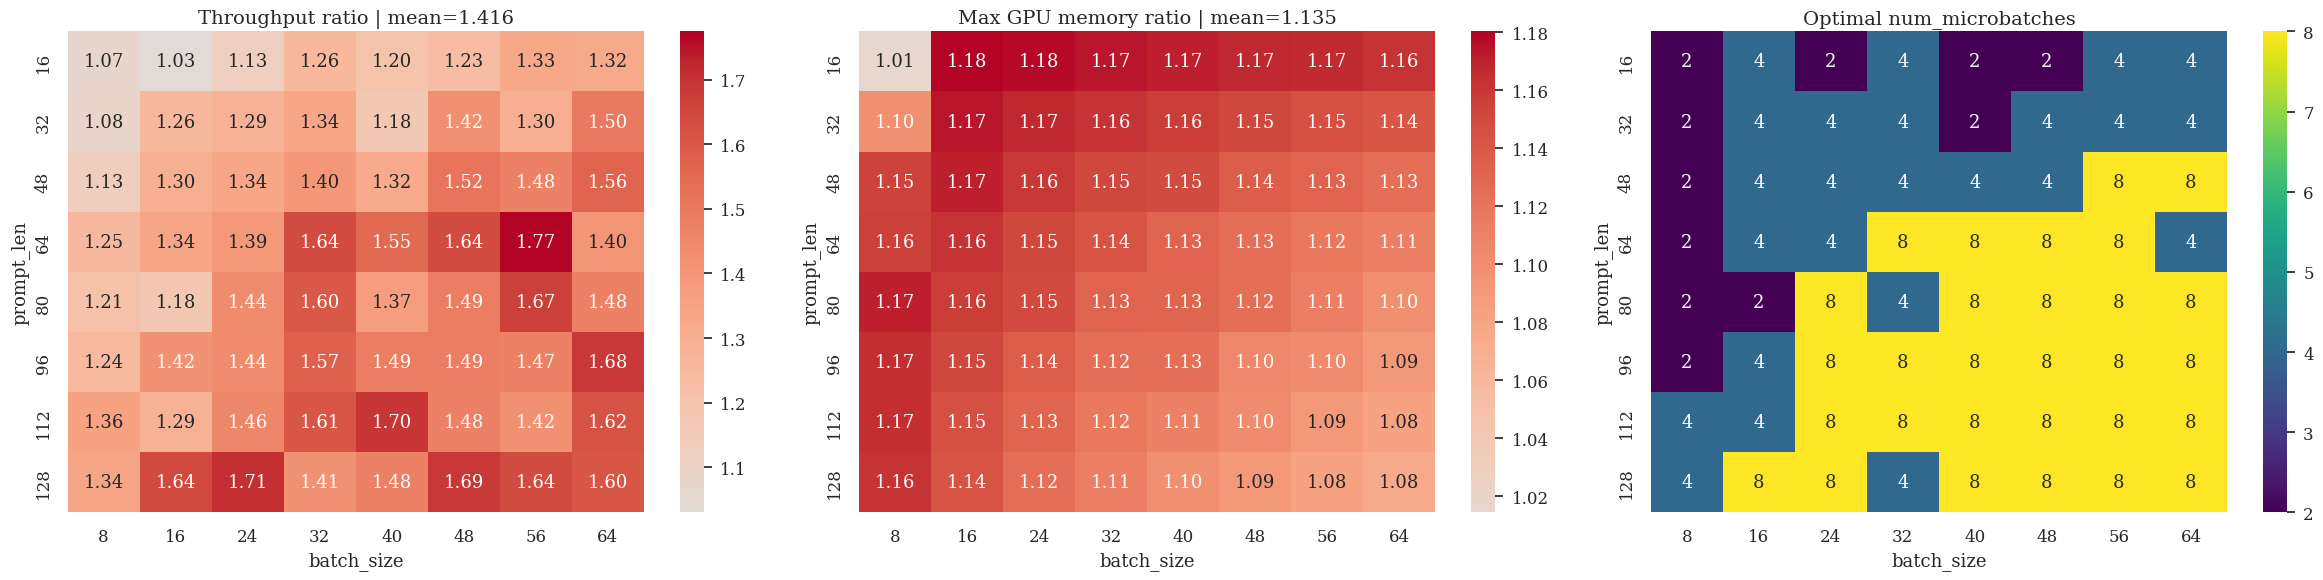

In [ ]:
df_1['max_gpu'] = df_1[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

best_idx = df_2.groupby(['prompt_len', 'batch_size'])['throughput (tokens/s)'].idxmax()
best_data2 = df_2.loc[best_idx].copy()
best_data2['max_gpu'] = best_data2[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

pivot_thr = best_data2.pivot_table(
    values='throughput (tokens/s)',
    index='prompt_len',
    columns='batch_size'
)
pivot_thr_base = df_1.pivot_table(
    values='throughput (tokens/s)',
    index='prompt_len',
    columns='batch_size'
)

pivot_mem = best_data2.pivot_table(
    values='max_gpu',
    index='prompt_len',
    columns='batch_size'
)
pivot_mem_base = df_1.pivot_table(
    values='max_gpu',
    index='prompt_len',
    columns='batch_size'
)

pivot_micro = best_data2.pivot_table(
    values='num_microbatches',
    index='prompt_len',
    columns='batch_size'
)

ratio_thr = pivot_thr / pivot_thr_base
ratio_mem = pivot_mem / pivot_mem_base

mean_ratio_thr = np.nanmean(ratio_thr.values)
mean_ratio_mem = np.nanmean(ratio_mem.values)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.heatmap(ratio_thr, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[0])
axes[0].set_title(f"Throughput ratio | mean={mean_ratio_thr:.3f}")
axes[0].set_xlabel("batch_size")
axes[0].set_ylabel("prompt_len")

sns.heatmap(ratio_mem, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[1])
axes[1].set_title(f"Max GPU memory ratio | mean={mean_ratio_mem:.3f}")
axes[1].set_xlabel("batch_size")
axes[1].set_ylabel("prompt_len")

sns.heatmap(pivot_micro, annot=True, fmt=".0f", cmap="viridis", ax=axes[2])
axes[2].set_title(f"Optimal num_microbatches")
axes[2].set_xlabel("batch_size")
axes[2].set_ylabel("prompt_len")

plt.tight_layout()
plt.show()

## Deberta

In [ ]:
df_1 = pd.read_csv("src/results/deberta/deberta_pipeline_1.csv")
df_2 = pd.read_csv("src/results/deberta/deberta_pipeline_2.csv")

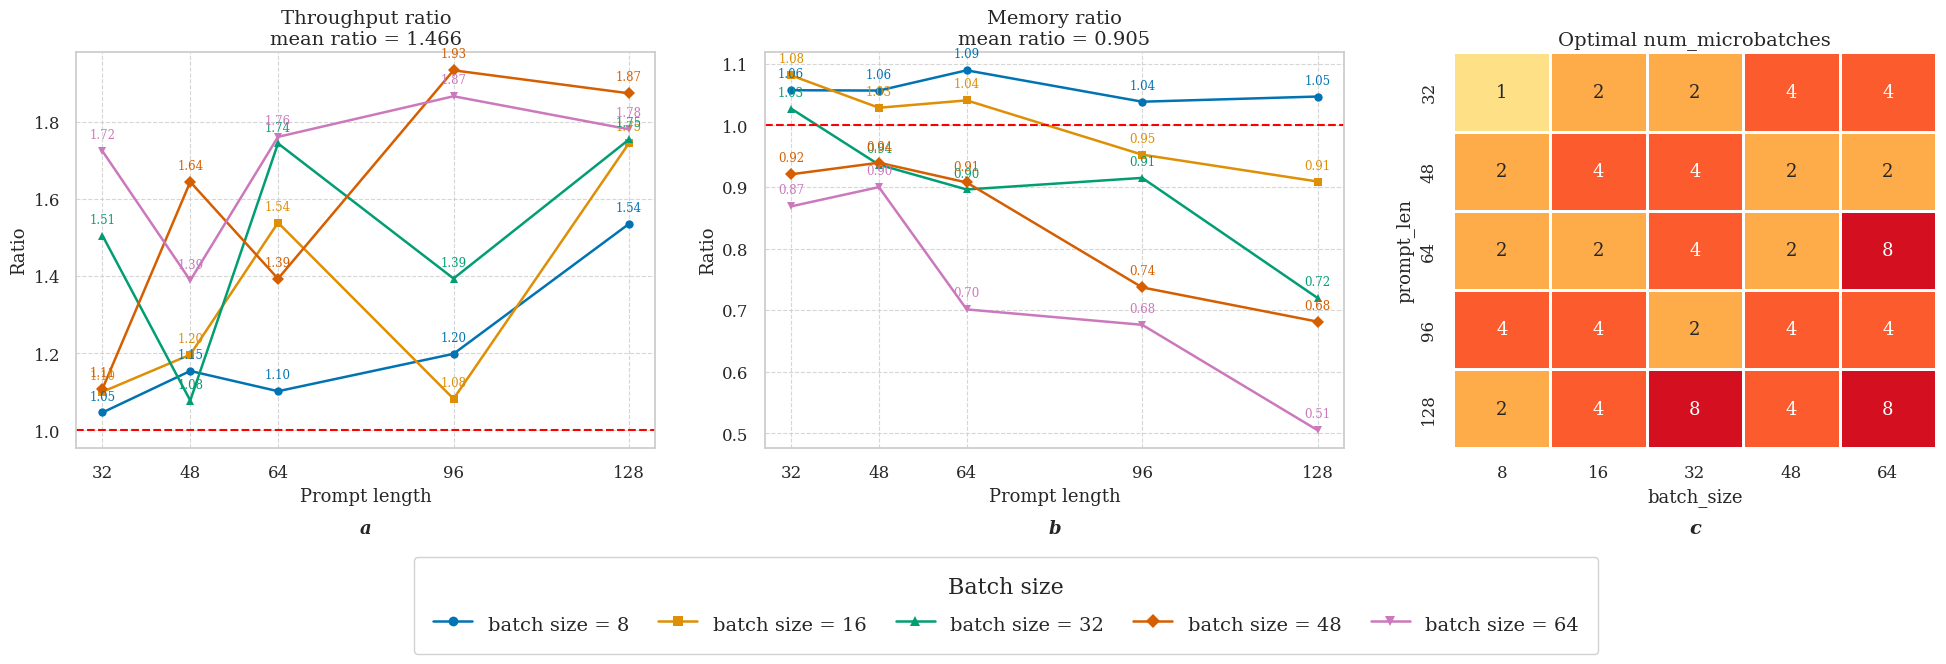

Saved to plot.svg


In [ ]:
plot_ratios_and_microbatches_encoder(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1'],
                             batch_sizes=[8, 16, 32, 48, 64],
                             prompt_lens_list=[32, 48, 64, 96, 128],
                             figsize_per_row=7,
                             save_path="deberta.svg")

## VIT-Giant(DinoV2)

In [ ]:
df_1 = pd.read_csv("src/results/dinov2/dinov2_pipeline_1.csv")
df_2 = pd.read_csv("src/results/dinov2/dinov2_pipeline_2.csv")

In [ ]:
def plot_ratios_and_microbatches_vit(
    df_1: pd.DataFrame,
    df_2: pd.DataFrame,
    gpus: List[str],
    batch_sizes: List[int] = None,
    save_path: str = 'plot.svg',
    figsize_per_row: int = 6,
):
    # ── Фильтрация ─────────────────────────────────────────────────────────
    df_1 = df_1.copy()
    df_2 = df_2.copy()

    if batch_sizes is not None:
        df_1 = df_1[df_1['batch_size'].isin(batch_sizes)]
        df_2 = df_2[df_2['batch_size'].isin(batch_sizes)]
    df_1['max_gpu'] = df_1[gpus].max(axis=1)
    df_2['max_gpu'] = df_2[gpus].max(axis=1)

    # ── Агрегация df_1 (baseline) ──────────────────────────────────────────
    df1_group = df_1.groupby(['batch_size']).mean(numeric_only=True).reset_index()

    # ── Лучший df_2 по throughput, затем группировка ──────────────────────
    best_idx   = df_2.groupby(['batch_size', 'num_microbatches'])['throughput (tokens/s)'].idxmax()
    best_data2 = df_2.loc[best_idx].copy()
    df2_group  = best_data2.groupby(['batch_size', 'num_microbatches']).mean(numeric_only=True).reset_index()

    # ── Pivot tables ───────────────────────────────────────────────────────
    pivot_thr = df2_group.pivot_table(
        values='throughput (tokens/s)',
        index='num_microbatches',
        columns='batch_size',
    )
    pivot_mem = df2_group.pivot_table(
        values='max_gpu',
        index='num_microbatches',
        columns='batch_size',
    )

    pivot_thr_base = df1_group.set_index('batch_size')['throughput (tokens/s)']
    pivot_mem_base = df1_group.set_index('batch_size')['max_gpu']

    # Broadcast baseline по строкам (num_microbatches)
    pivot_thr_base = pd.DataFrame(
        [pivot_thr_base] * len(pivot_thr.index),
        index=pivot_thr.index,
        columns=pivot_thr_base.index,
    )
    pivot_mem_base = pd.DataFrame(
        [pivot_mem_base] * len(pivot_mem.index),
        index=pivot_mem.index,
        columns=pivot_mem_base.index,
    )

    ratio_thr = pivot_thr / pivot_thr_base
    ratio_mem = pivot_mem / pivot_mem_base

    mean_ratio_thr = np.nanmean(ratio_thr.values)
    mean_ratio_mem = np.nanmean(ratio_mem.values)

    all_batch_sizes  = sorted(ratio_thr.columns.tolist())
    all_microbatches = sorted(ratio_thr.index.tolist())

    # ── Стиль ─────────────────────────────────────────────────────────────
    plt.rcParams.update({
        'font.size': 13,
        'font.family': 'serif',
        'axes.titlesize': 14,
        'axes.labelsize': 13,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 11,
    })

    cmap_lines = sns.color_palette("colorblind", len(all_microbatches))
    color_map  = {mb: cmap_lines[i] for i, mb in enumerate(all_microbatches)}
    markers    = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
    marker_map = {mb: markers[i % len(markers)] for i, mb in enumerate(all_microbatches)}

    # ── Фигура: основная сетка (1×2) + нижняя полоса легенды ──────────────
    LETTER_PAD   = -0.18
    legend_ratio = 0.10

    fig = plt.figure(figsize=(16, figsize_per_row))

    outer = GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[1, legend_ratio / (1 - legend_ratio)],
        hspace=0.45,
    )
    inner = GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=outer[0],
        wspace=0.15,
    )

    ax_thr = fig.add_subplot(inner[0, 0])
    ax_mem = fig.add_subplot(inner[0, 1])
    ax_leg = fig.add_subplot(outer[1])
    ax_leg.axis('off')

    # ── Вспомогательная: line plot ─────────────────────────────────────────
    def draw_line_plot(ax, ratio_pivot, title, ylabel, label, mean_val):
        # ratio_pivot: index=num_microbatches, columns=batch_size
        # Нам нужно: x=batch_size, линия=num_microbatches
        # → транспонируем для удобства итерации
        for mb in all_microbatches:
            if mb not in ratio_pivot.index:
                continue
            vals = ratio_pivot.loc[mb, all_batch_sizes].values
            ax.plot(
                all_batch_sizes, vals,
                color=color_map[mb],
                marker=marker_map[mb],
                linewidth=1.8,
                markersize=6,
                label=f'num_microbatches = {mb}',
            )
            for x, y in zip(all_batch_sizes, vals):
                if not np.isnan(y):
                    ax.annotate(
                        f'{y:.2f}',
                        xy=(x, y),
                        xytext=(0, 7),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=8.5,
                        color=color_map[mb],
                    )
        ax.axhline(1.0, linestyle='--', color='red')
        ax.set_xlabel("Batch size")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title}\nmean ratio = {mean_val:.3f}")
        ax.set_xticks(all_batch_sizes)
        ax.grid(axis='y', alpha=0.8, linestyle='--', linewidth=0.8)
        ax.grid(axis='x', alpha=0.8, linestyle='--', linewidth=0.8)

        ax.text(
            0.5, LETTER_PAD, f'{label}',
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=13, fontstyle='italic', fontweight='bold',
        )

    # ── Line plots ─────────────────────────────────────────────────────────
    draw_line_plot(ax_thr, ratio_thr, "Throughput ratio", "Ratio", 'a', mean_ratio_thr)
    draw_line_plot(ax_mem, ratio_mem, "Memory ratio",     "Ratio", 'b', mean_ratio_mem)

    # ── Нижняя легенда ─────────────────────────────────────────────────────
    line_handles = [
        mlines.Line2D(
            [], [],
            color=color_map[mb],
            marker=marker_map[mb],
            linewidth=1.8,
            markersize=7,
            label=f'num_microbatches = {mb}',
        )
        for mb in all_microbatches
    ]

    ax_leg.legend(
        handles=line_handles,
        loc='upper center',
        ncol=len(all_microbatches),
        title='Num microbatches',
        title_fontsize=14,
        fontsize=12,
        frameon=True,
        framealpha=0.9,
        edgecolor='#cccccc',
        borderpad=1.0,
        labelspacing=0.7,
        handlelength=2.0,
        handleheight=1.4,
        columnspacing=1.5,
    )

    plt.savefig(save_path, format='svg', bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")

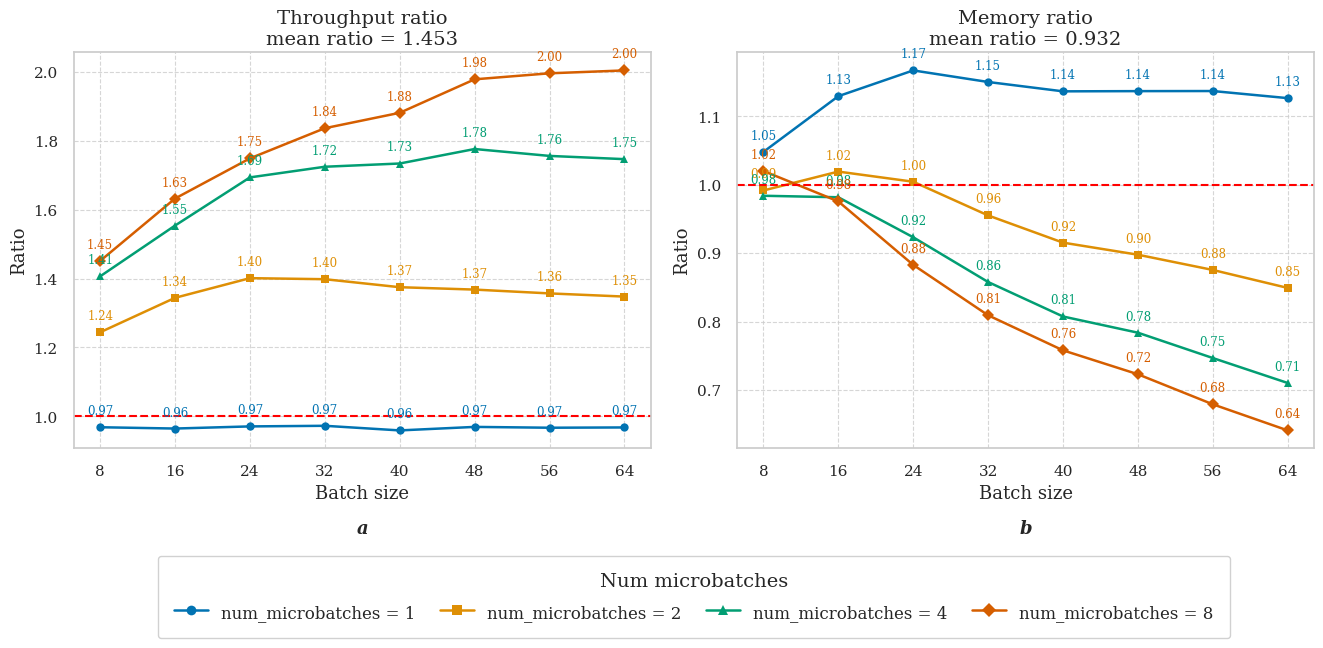

Saved to plot.svg


In [ ]:
plot_ratios_and_microbatches_vit(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1'],
                             figsize_per_row=7,
                             save_path="dinov2.svg")

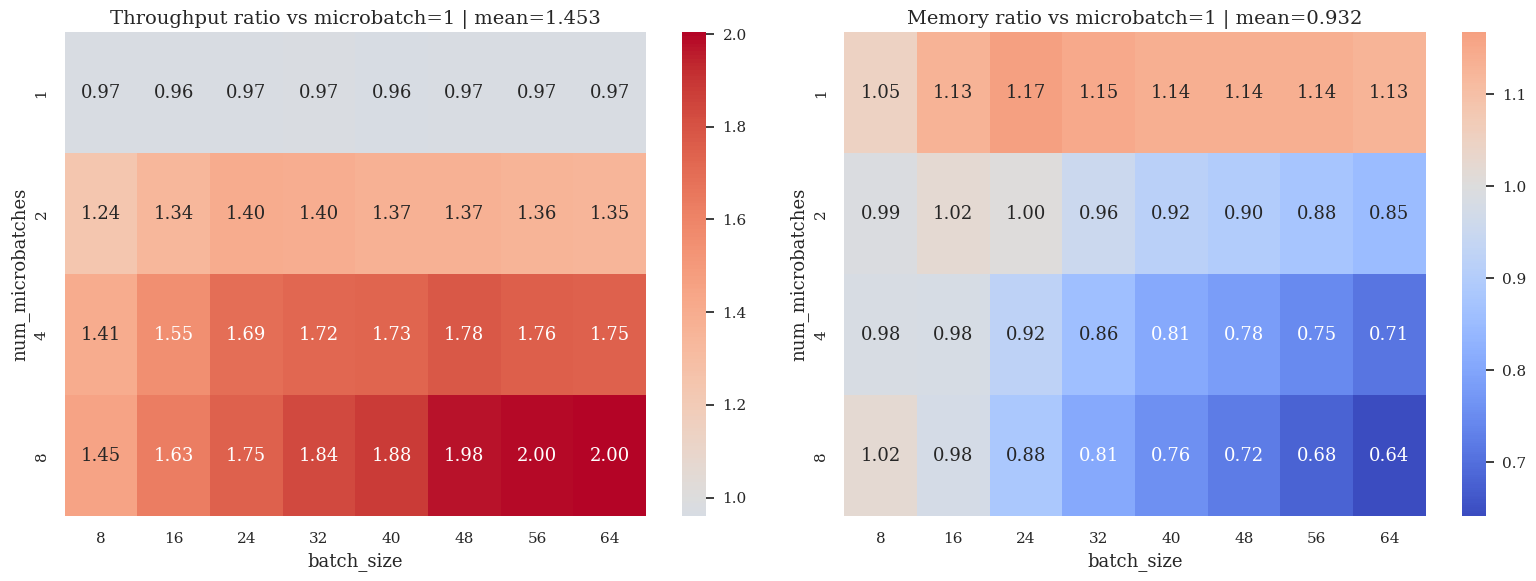

In [ ]:
df_1['max_gpu'] = df_1[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)
df_2['max_gpu'] = df_2[['peak memory GPU:0', 'peak memory GPU:1']].max(axis=1)

df1_group = df_1.groupby(['batch_size']).mean().reset_index()

best_idx = df_2.groupby(['batch_size', 'num_microbatches'])['throughput (tokens/s)'].idxmax()
best_data2 = df_2.loc[best_idx].copy()

df2_group = best_data2.groupby(['batch_size', 'num_microbatches']).mean().reset_index()

pivot_thr = df2_group.pivot_table(
    values='throughput (tokens/s)',
    index='num_microbatches',
    columns='batch_size'
)

pivot_mem = df2_group.pivot_table(
    values='max_gpu',
    index='num_microbatches',
    columns='batch_size'
)

pivot_thr_base = df1_group.set_index('batch_size')['throughput (tokens/s)']
pivot_mem_base = df1_group.set_index('batch_size')['max_gpu']

pivot_thr_base = pd.DataFrame([pivot_thr_base] * len(pivot_thr.index),
                              index=pivot_thr.index)

pivot_mem_base = pd.DataFrame([pivot_mem_base] * len(pivot_mem.index),
                              index=pivot_mem.index)

ratio_thr = pivot_thr / pivot_thr_base
ratio_mem = pivot_mem / pivot_mem_base

mean_ratio_thr = np.nanmean(ratio_thr.values)
mean_ratio_mem = np.nanmean(ratio_mem.values)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(ratio_thr, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[0])
axes[0].set_title(f"Throughput ratio vs microbatch=1 | mean={mean_ratio_thr:.3f}")
axes[0].set_xlabel("batch_size")
axes[0].set_ylabel("num_microbatches")

sns.heatmap(ratio_mem, annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[1])
axes[1].set_title(f"Memory ratio vs microbatch=1 | mean={mean_ratio_mem:.3f}")
axes[1].set_xlabel("batch_size")
axes[1].set_ylabel("num_microbatches")

plt.tight_layout()
plt.show()

## Bloom-3B

In [ ]:
df_1 = pd.read_csv("src/results/bloom/bloom-3b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/bloom/bloom-3b_pipeline_2.csv")

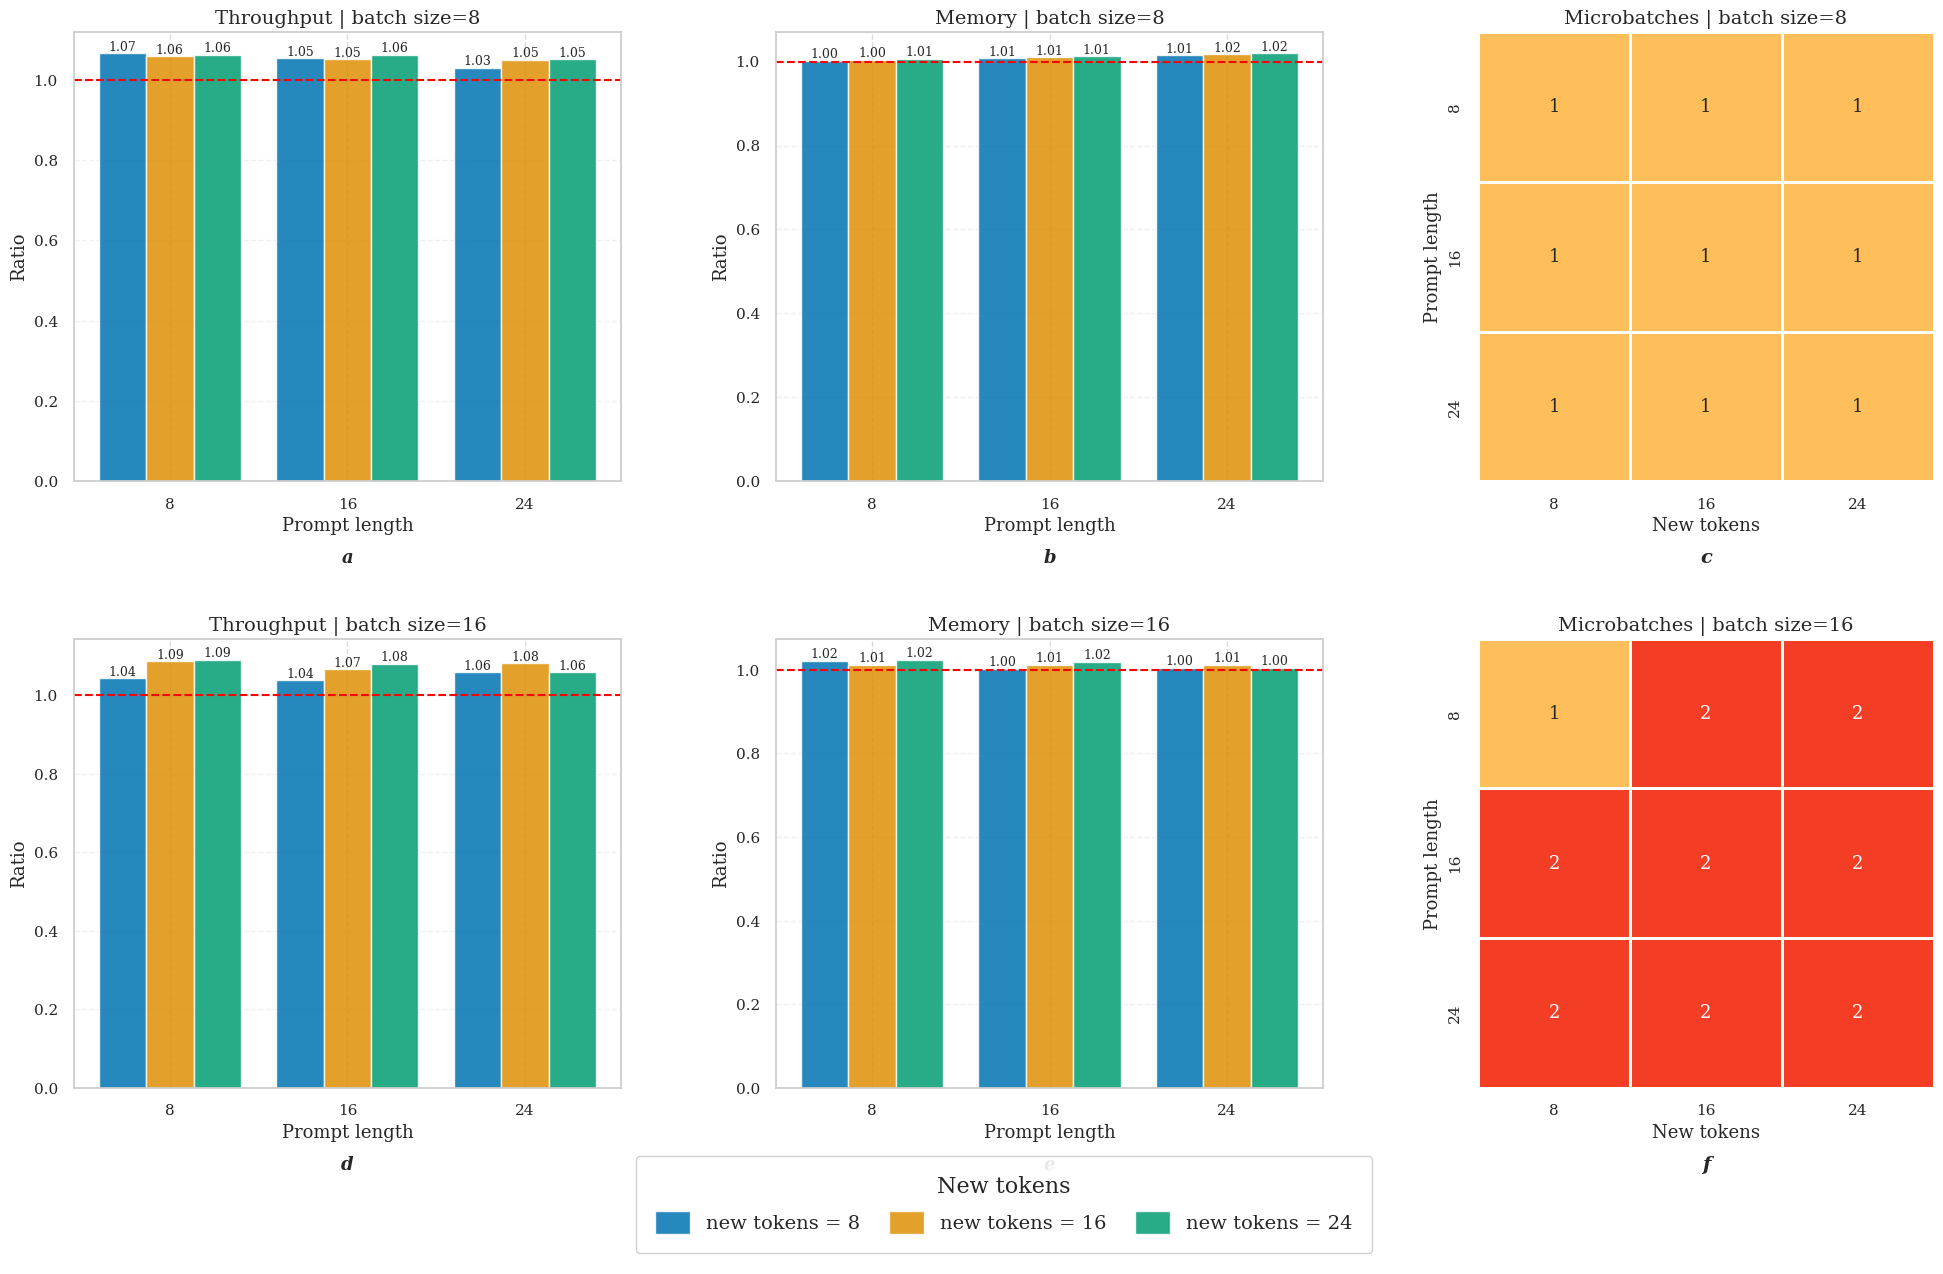

Saved to plot.svg


In [ ]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             gpus=['peak memory GPU:0', 'peak memory GPU:1'],
                             batch_sizes=[8, 16],
                             prompt_lens_list=[8, 16, 24],
                             new_tokens_list=[8, 16, 24],
                             figsize_per_row=8,
                             bar_width_fraction=0.8,
                             save_path="bloom-3b.svg")

## OPT-2.7B

In [ ]:
df_1 = pd.read_csv("src/results/opt/opt-2.7b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/opt/opt-2.7b_pipeline_2.csv")

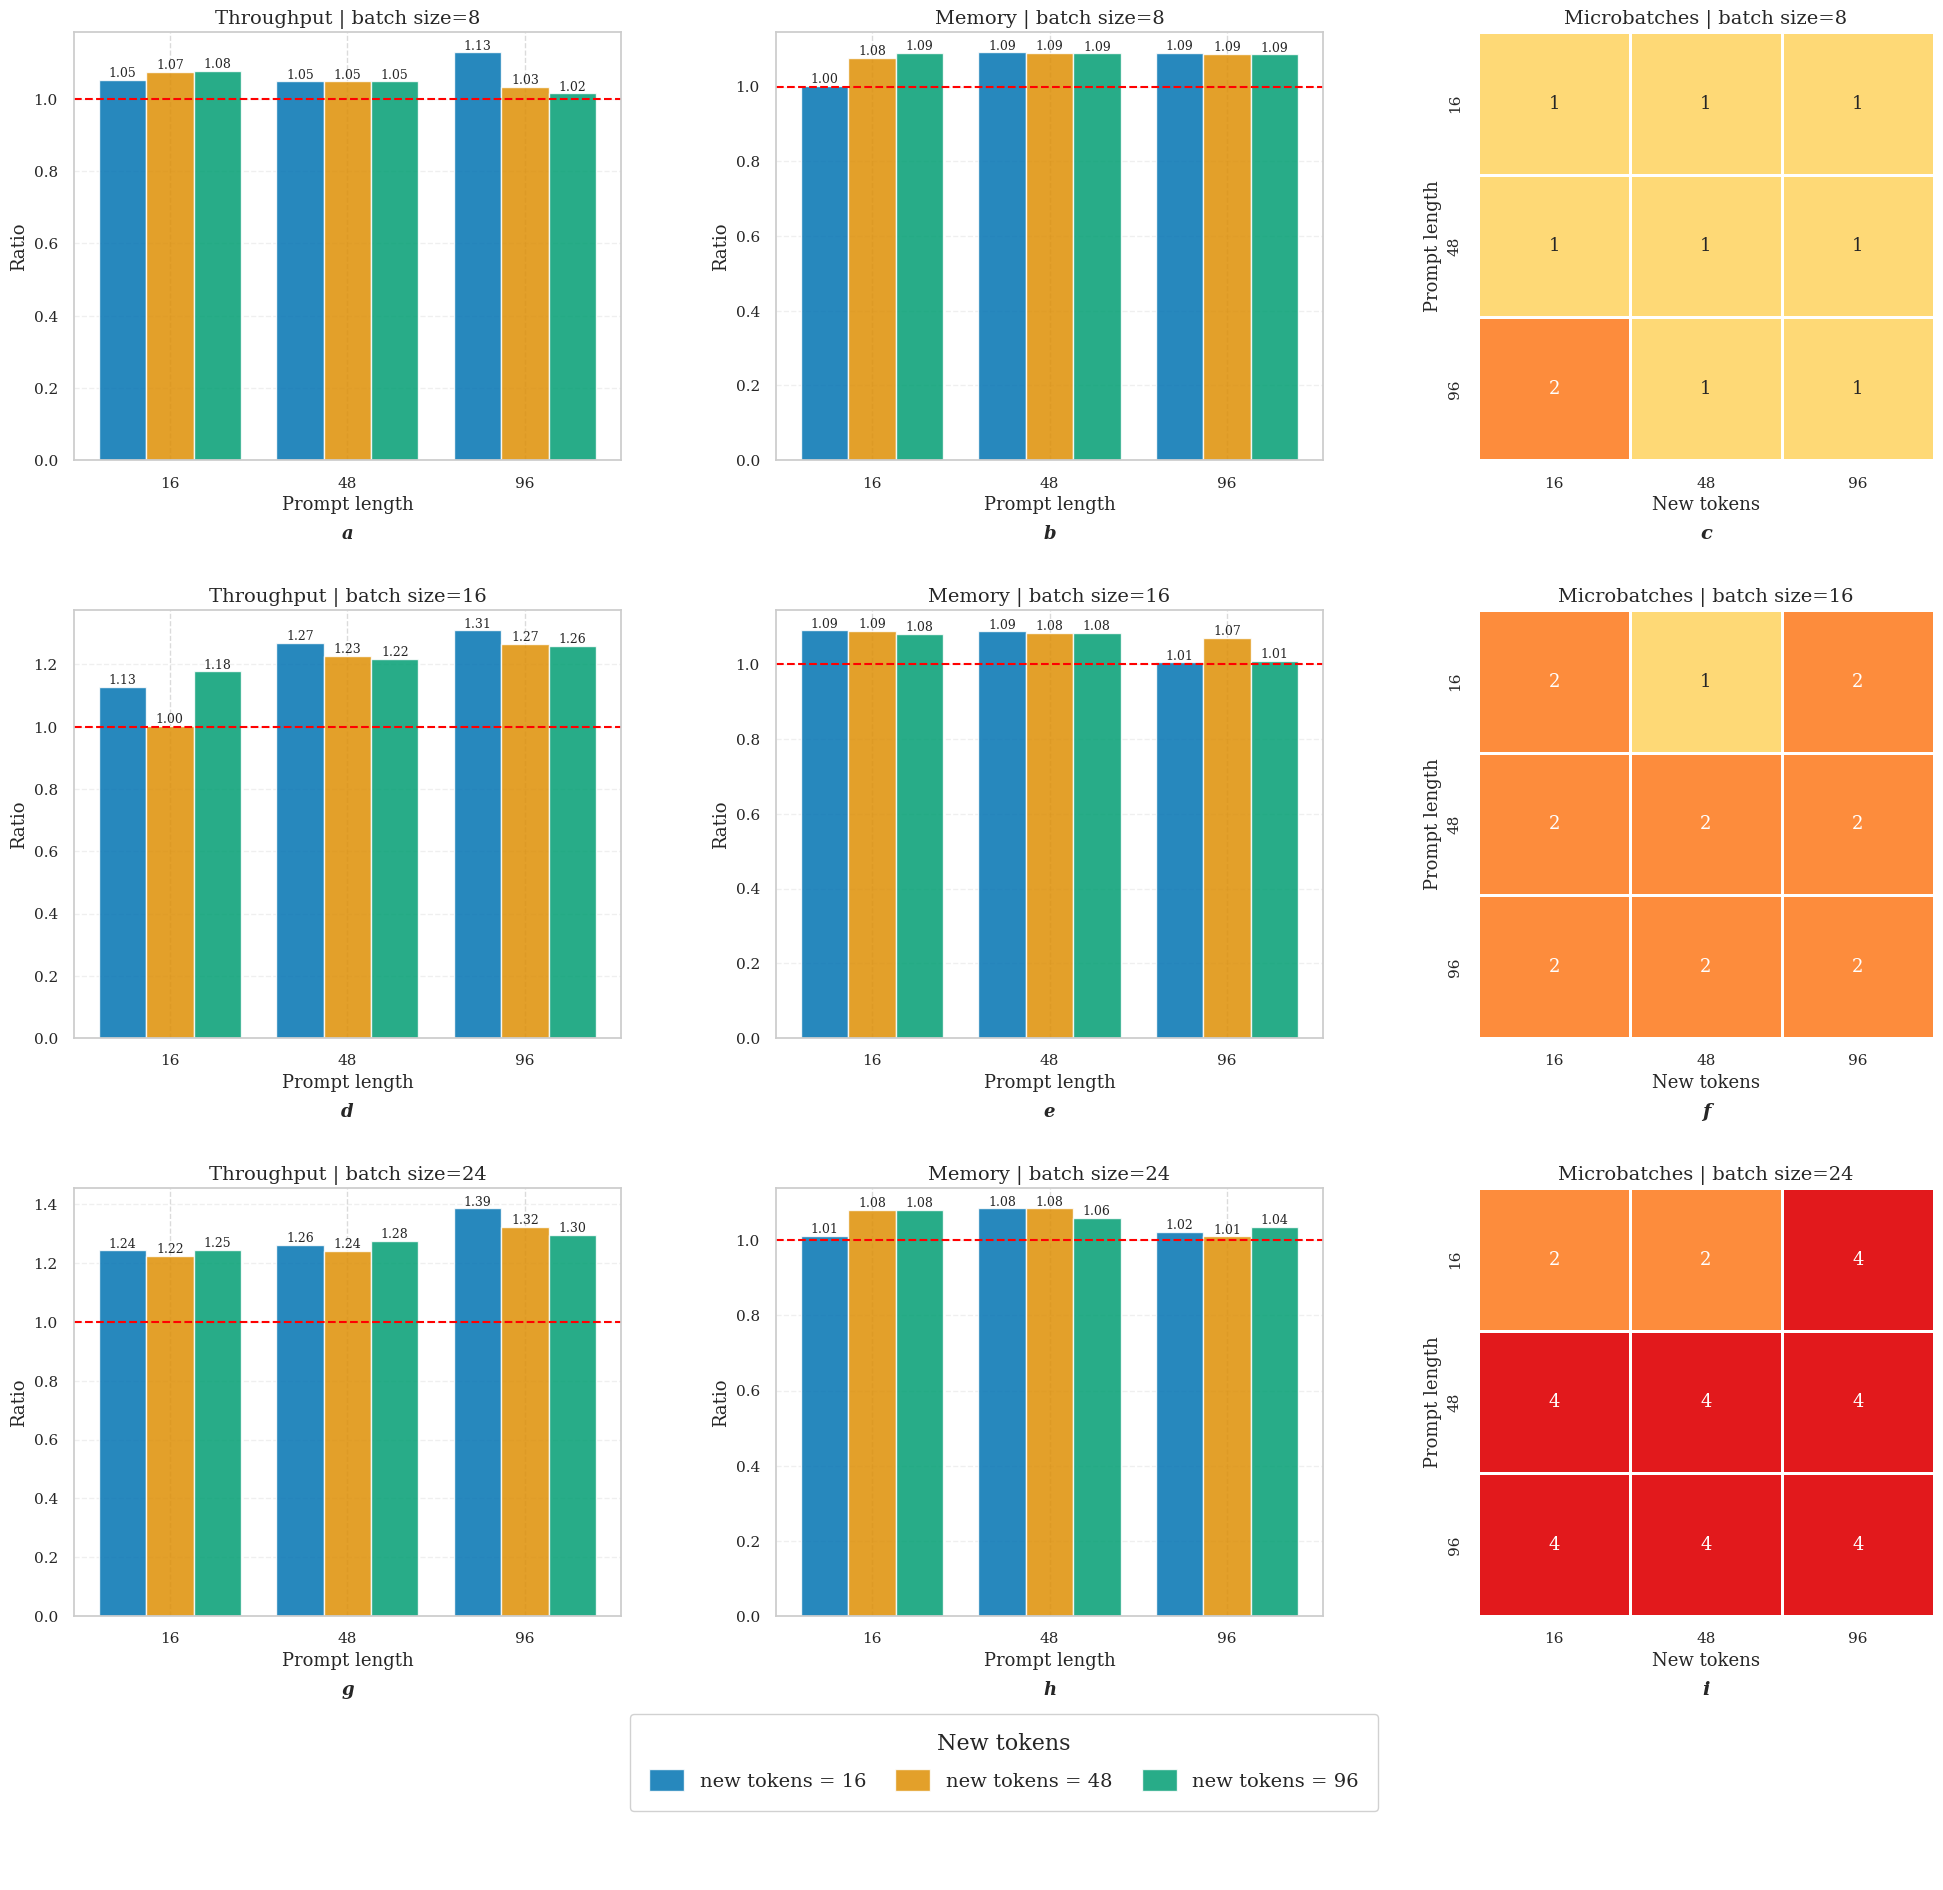

Saved to plot.svg


In [ ]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1'],
                             batch_sizes=[8, 16, 24],
                             prompt_lens_list=[16, 48, 96],
                             new_tokens_list=[16, 48, 96],
                             figsize_per_row=8,
                             bar_width_fraction=0.8)

## OPT-13B

In [ ]:
df_1 = pd.read_csv("src/results/opt/opt-13b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/opt/opt-13b_pipeline_2.csv")

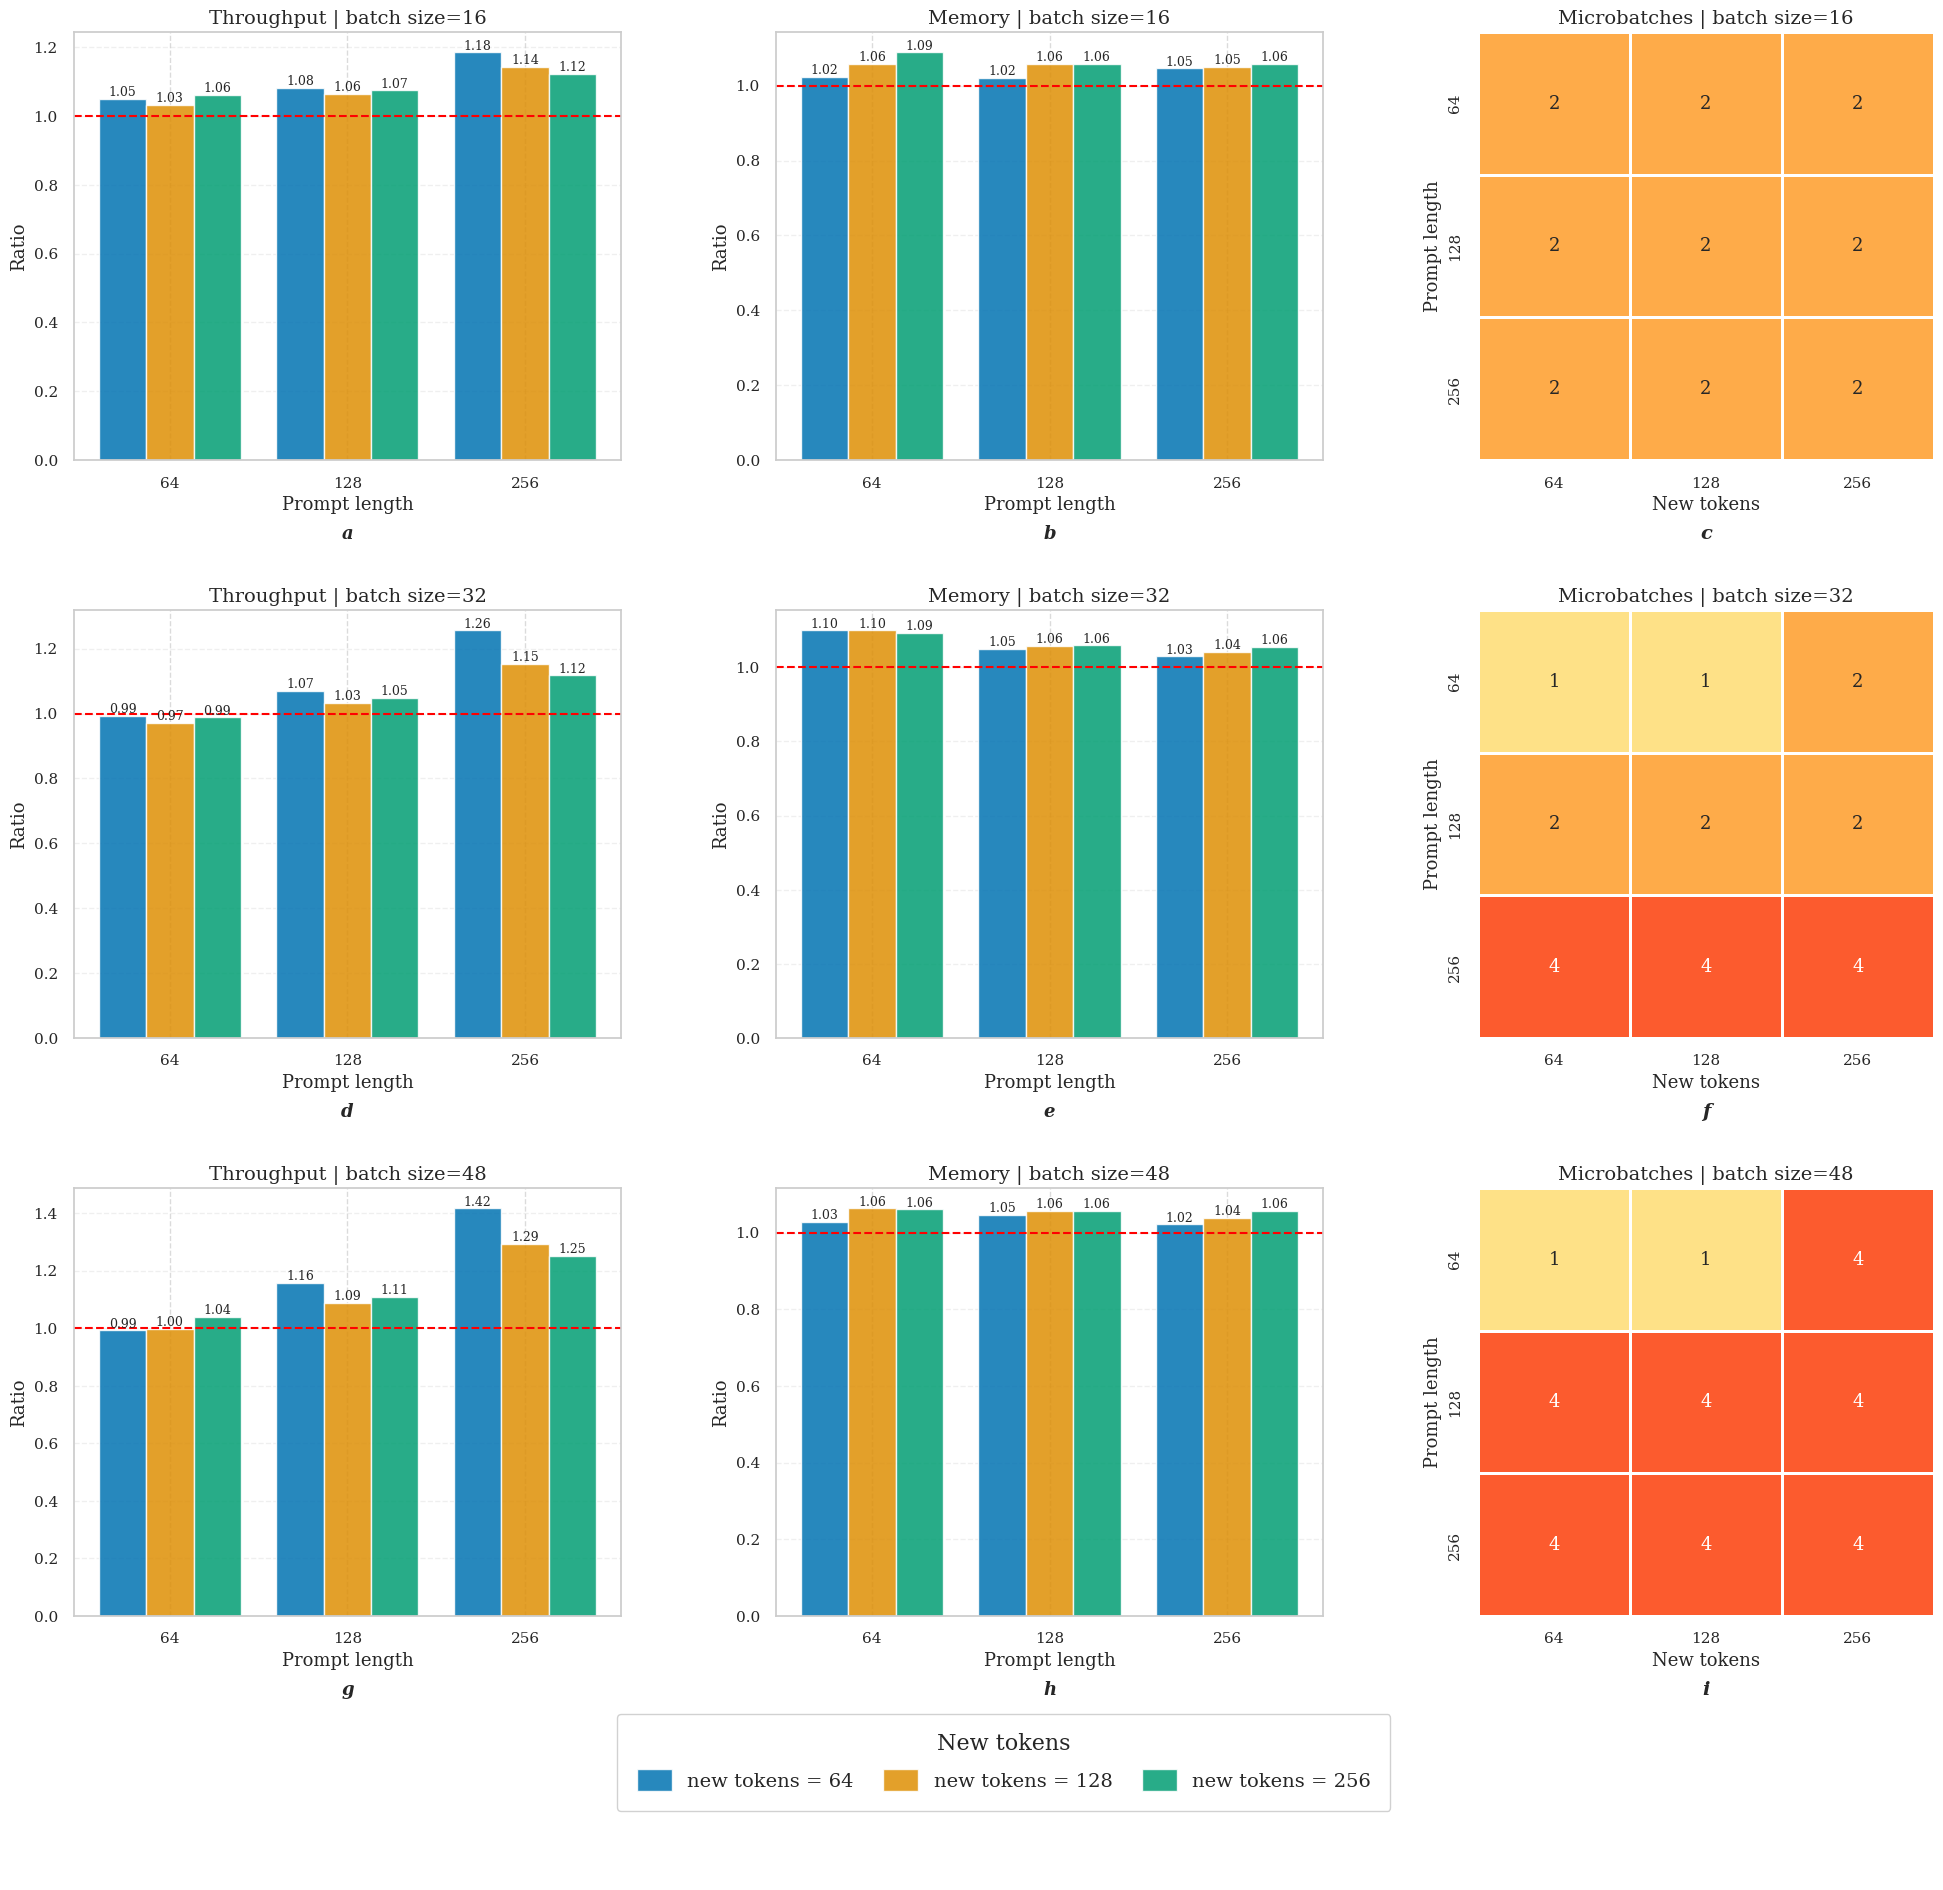

Saved to plot.svg


In [ ]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1', 'peak memory GPU:2', 'peak memory GPU:3'],
                             batch_sizes=[16, 32, 48],
                             prompt_lens_list=[64, 128, 256],
                             new_tokens_list=[64, 128, 256],
                             figsize_per_row=8,
                             bar_width_fraction=0.8,
                             save_path="opt-13b.svg")

## OPT-6.7B

In [ ]:
df_1 = pd.read_csv("src/results/opt/opt-6.7b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/opt/opt-6.7b_pipeline_2.csv")

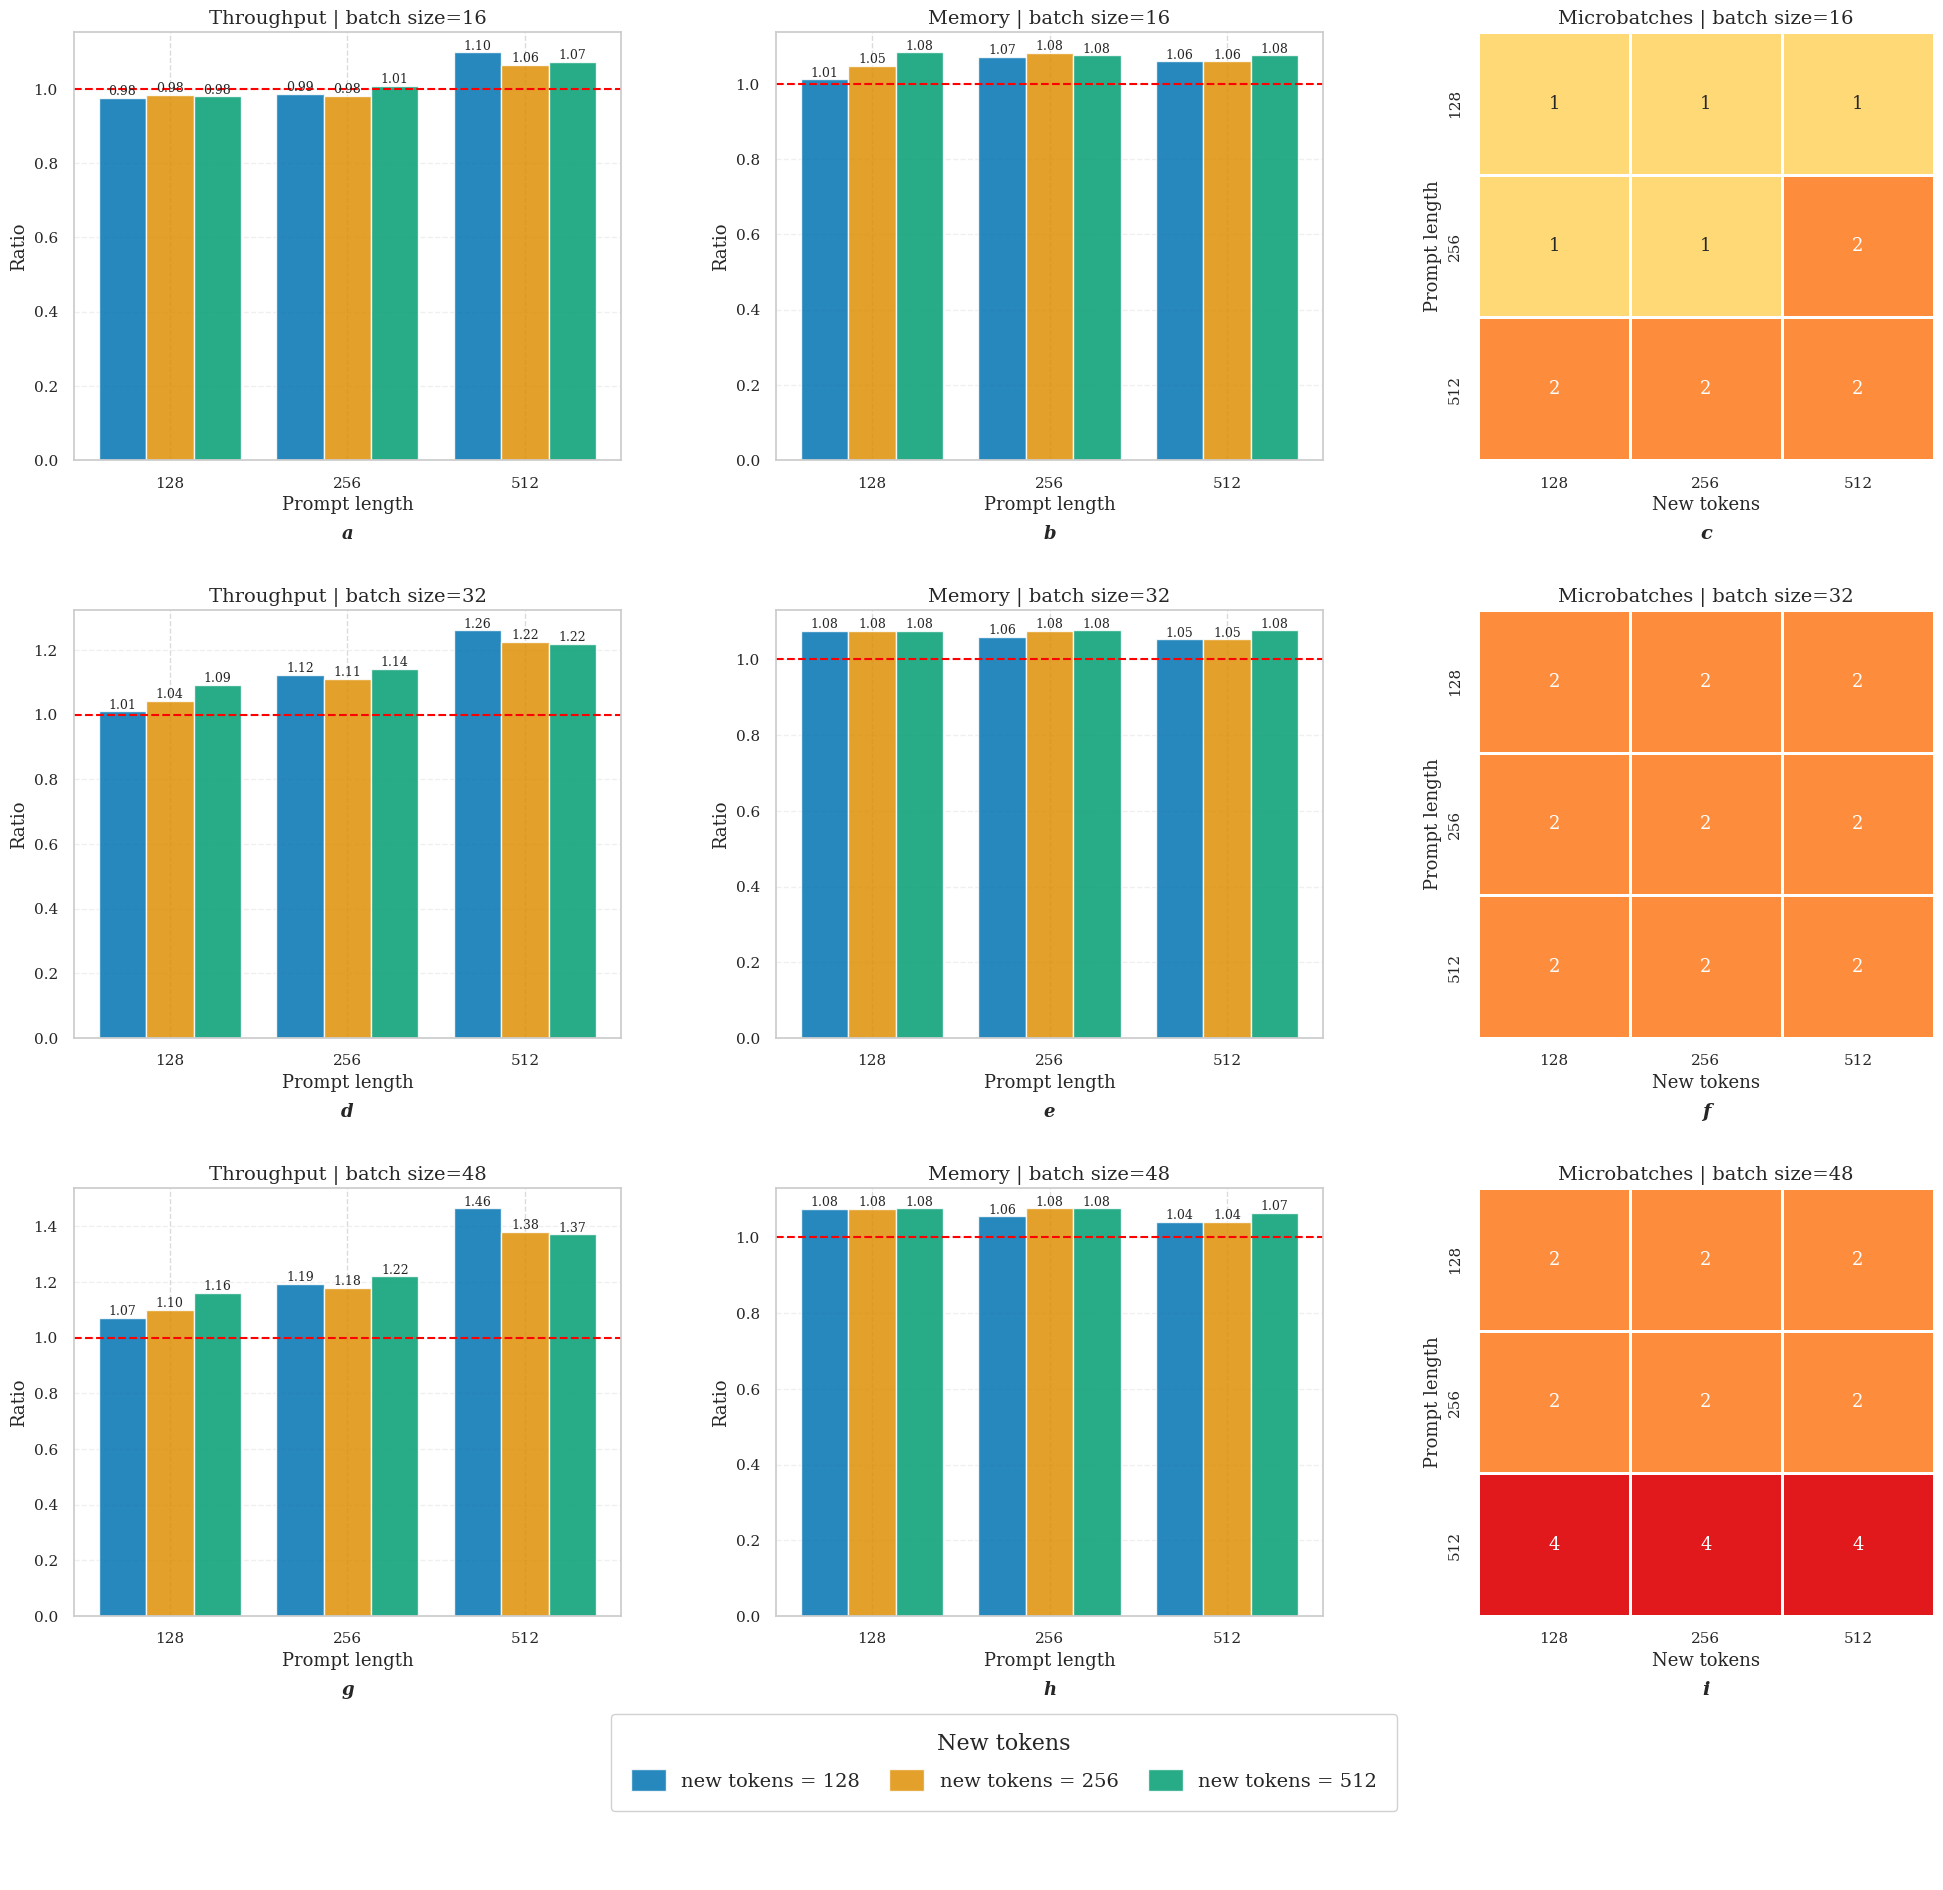

Saved to plot.svg


In [ ]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             gpus=['peak memory GPU:0', 'peak memory GPU:1', 'peak memory GPU:2', 'peak memory GPU:3'],
                             batch_sizes=[16, 32, 48],
                             prompt_lens_list=[128, 256, 512],
                             new_tokens_list=[128, 256, 512],
                             figsize_per_row=8,
                             bar_width_fraction=0.8,
                             save_path="opt-6.7b.svg")

## BLOOM-7B1

In [ ]:
df_1 = pd.read_csv("src/results/bloom/bloom-7b1_pipeline_1.csv")
df_2 = pd.read_csv("src/results/bloom/bloom-7b1_pipeline_2.csv")

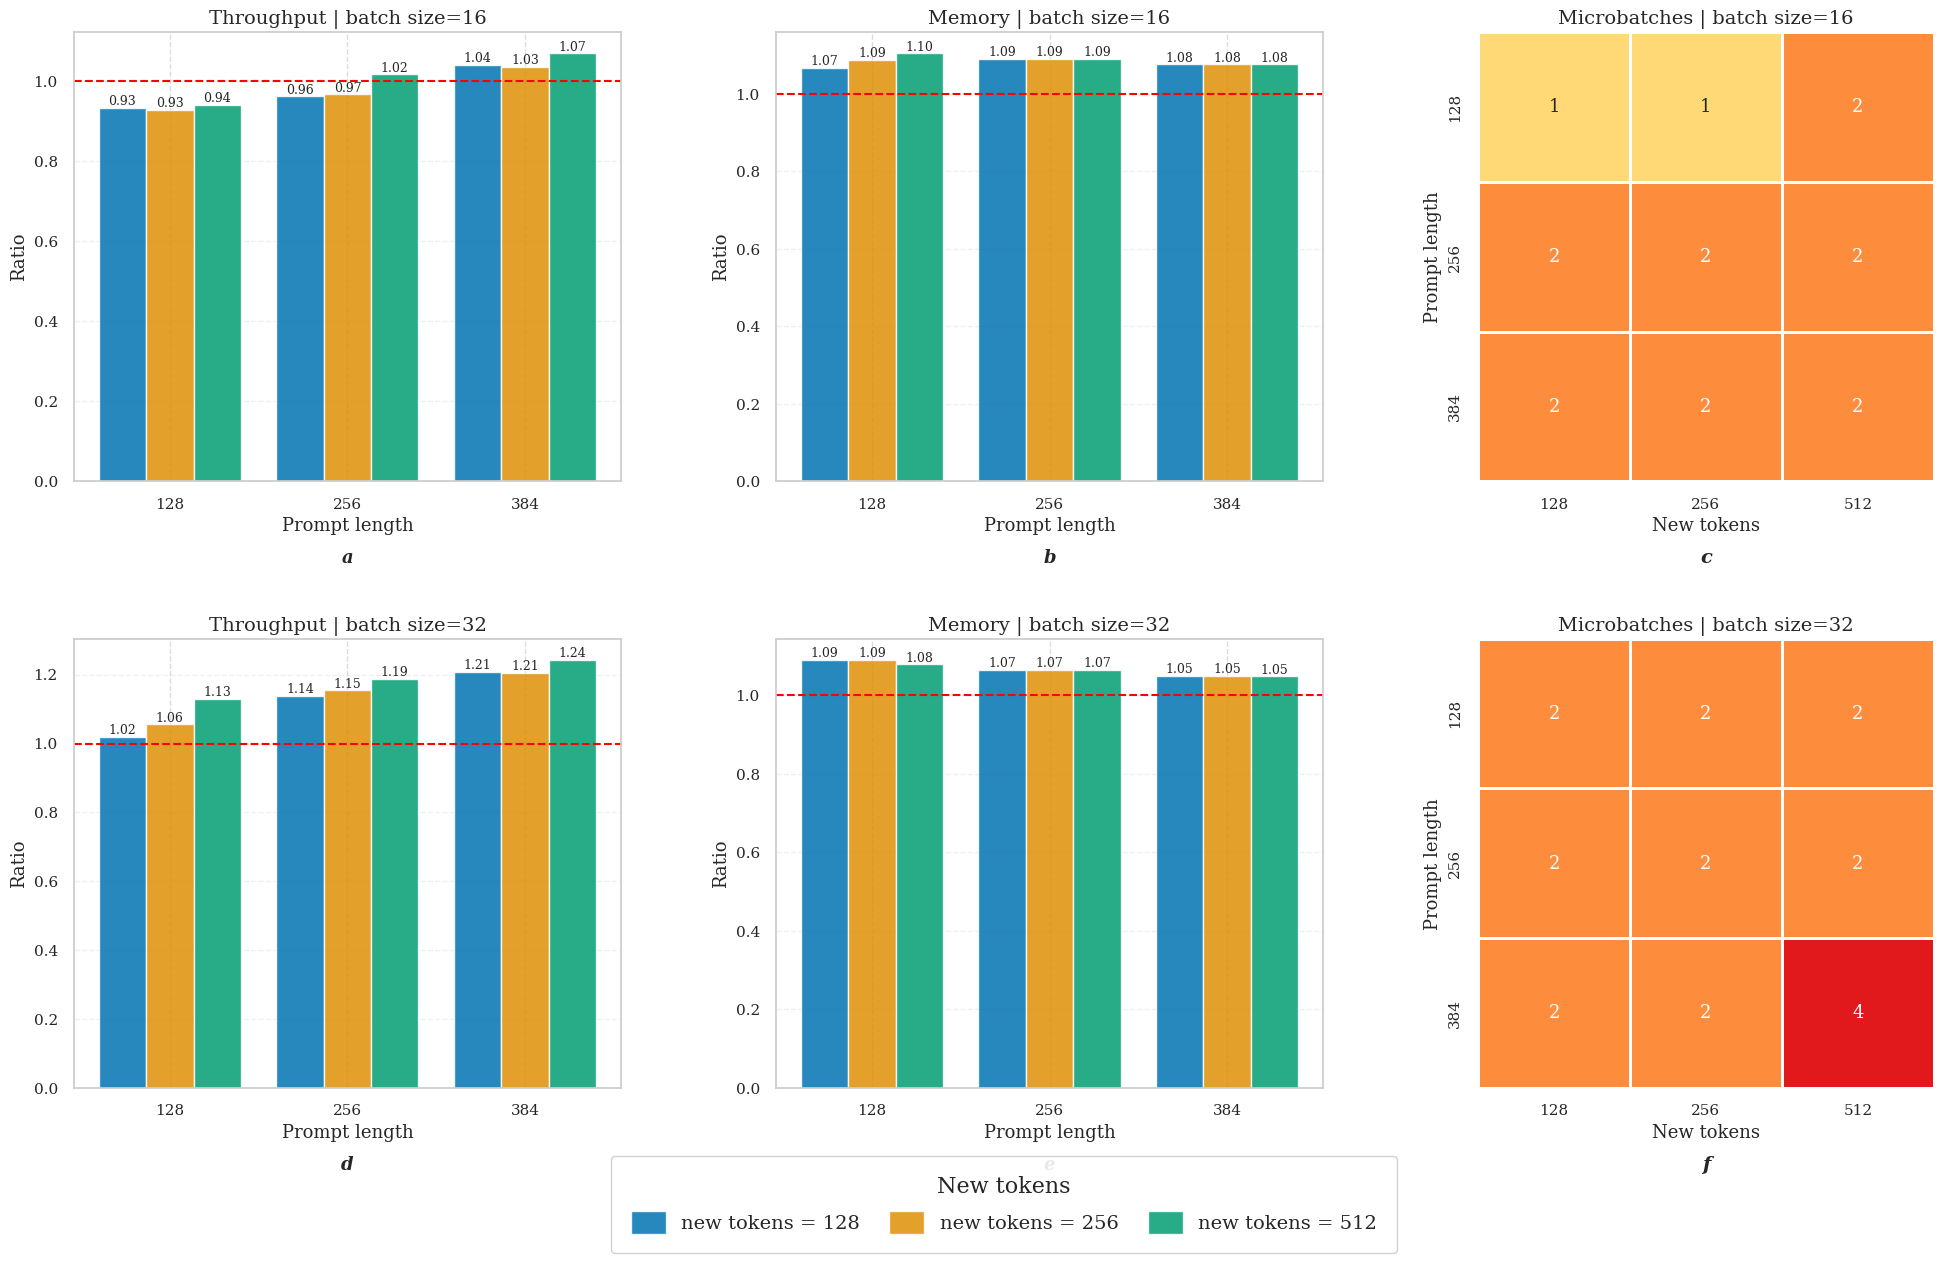

Saved to plot.svg


In [ ]:
plot_ratios_and_microbatches_decoder(df_1, df_2,
                             gpus=['peak memory GPU:0', 'peak memory GPU:1', 'peak memory GPU:2', 'peak memory GPU:3'],
                             batch_sizes=[16, 32],
                             prompt_lens_list=[128, 256, 384],
                             new_tokens_list=[128, 256, 512],
                             figsize_per_row=8,
                             bar_width_fraction=0.8,
                             save_path="bloom-7b1.svg")

## internVIT-6b

In [ ]:
df_1 = pd.read_csv("src/results/intern/intern-6b_pipeline_1.csv")
df_2 = pd.read_csv("src/results/intern/intern-6b_pipeline_2.csv")

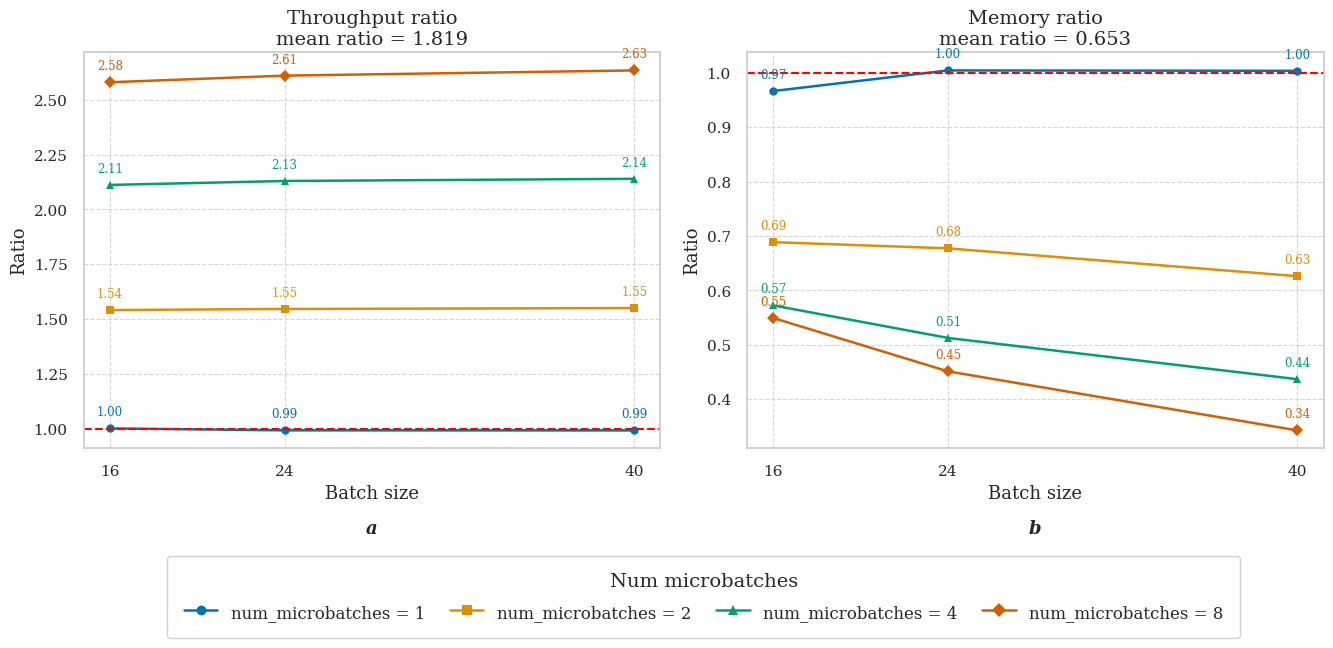

Saved to plot.svg


In [ ]:
plot_ratios_and_microbatches_vit(df_1, df_2,
                             ['peak memory GPU:0', 'peak memory GPU:1', 'peak memory GPU:2', 'peak memory GPU:3'],
                             figsize_per_row=7,
                             save_path="intern.svg")